# 101_01 — Simulación y preprocesamiento · Escenario A-1 (ARFIMA de memoria larga)

Paso **1 de 5** del ciclo `Python → MATLAB → Python`:
- 01: **este notebook** genera los datos, ajusta base + FPCA (**sin estandarizar los scores**), escribe los datasets AR
- 02: `psbp_fd_iteracion.m` muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento
- 03, 04, 05: `101_03_convergencia` / `101_04_evaluacion` / `101_05_comparacion`

Nota: acá sólo se simulan los objetos para entrenar en el muestreador y para ajustar el FAR en R.

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de experimento. Todo lo demás se deriva de ellas.

> **Diseño de la corrida 101.** Cada componente FPCA usa **solo su rezago propio** como covariable (sin dependencia cruzada). Así la componente $k$ no depende de $M$: se entrena una sola vez en $M=$`M_ENTRENO` y los $M$ menores reutilizan sus trazas (`hyperparameters.json["trazas_en"]`).

## 1. Imports y rutas

In [1]:
import json
import math
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenarioA1, generar_escenario_A1, autocorrelacion_arfima,
    guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
# Rutas del contrato y convención del EXPERIMENT_ID: el gemelo Python de
# config_paths.m. Antes esta sección armaba el dict PATHS a mano.
from model_psbp_fd.utils import (
    get_project_root, experiment_id, normalizar_lista_M,
    rutas_por_M, guardar_en_todos, replicar_figura,
)
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento y barrido en $M$

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario_101"
ESCENARIO_ID = 1      # Algoritmo A-1: ARFIMA(0,d,0) de memoria larga
REPLICA_ID   = 1      # réplica Monte Carlo
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

M_FPCA_LIST = (1, 2, 3, 4, 5, 6, 7, 8)

LIMPIAR_DIRECTORIOS = True

# FUnciones
M_FPCA_LIST     = normalizar_lista_M(M_FPCA_LIST)
M_ENTRENO       = max(M_FPCA_LIST)   # único M que se entrena en MATLAB
EXPERIMENT_BASE = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"EXPERIMENT_BASE : {EXPERIMENT_BASE}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")
print(f"barrido en M    : {list(M_FPCA_LIST)}   (se entrena solo M={M_ENTRENO})")
for _M in M_FPCA_LIST:
    print(f"   M={_M}  ->  {experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M)}")

PROJECT_ROOT    : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_BASE : escenario_101_1_r01
Escenario 1 · réplica 1 · seed base 41232
barrido en M    : [1, 2, 3, 4, 5, 6, 7, 8]   (se entrena solo M=8)
   M=1  ->  escenario_101_1_r01_m01
   M=2  ->  escenario_101_1_r01_m02
   M=3  ->  escenario_101_1_r01_m03
   M=4  ->  escenario_101_1_r01_m04
   M=5  ->  escenario_101_1_r01_m05
   M=6  ->  escenario_101_1_r01_m06
   M=7  ->  escenario_101_1_r01_m07
   M=8  ->  escenario_101_1_r01_m08


In [3]:
PATHS_POR_M = rutas_por_M(BASENAME, ESCENARIO_ID, REPLICA_ID, M_FPCA_LIST,
                          dominio="simulaciones", project_root=PROJECT_ROOT,
                          limpiar=LIMPIAR_DIRECTORIOS)

for M, p in PATHS_POR_M.items():
    print(f"M={M}  ({experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)})")
    for nombre, ruta in p.items():
        print(f"  {nombre:12s} -> {ruta}")

M=1  (escenario_101_1_r01_m01)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m01
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_101_1_r01_m01
  predict      -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_101_1_r01_m01
  out_report   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_101_1_r01_m01
  out_artefact -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_101_1_r01_m01
M=2  (escenario_101_1_r01_m02)
  raw          -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m02
  functional   -> C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_101_1_r01_m02
  predict      -> C:\Us

## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

`sim_escenario_A1`: se simula UNA trayectoria escalar de largo
$(\text{burn\_in}+T)\cdot L$ por Davies–Harte y se corta en bloques contiguos
de largo $L$. Los dos parámetros del mecanismo son los del Cuadro
`tab:ane_algA1` del anexo:

| símbolo | qué es | valor |
|---|---|---|
| $d$ | memoria larga, en $(0,1/2)$ | 0.4 |
| $\sigma_Z$ | desviación marginal de $Z_s$ | 0.5 |

`sigma_zeta^2` se despeja de $\sigma_Z$ para que $\mathrm{Var}(Z_s)=\sigma_Z^2$
sea invariante en $d$; aquí no se usa para simular —la simulación va por las
autocovarianzas— y se reporta sólo como diagnóstico.

`burn_in` es **cosmético** en este escenario: Davies–Harte entrega una
trayectoria exactamente estacionaria, así que descartar bloques no corrige
nada. Se respeta por contrato de `ConfigObservacion` y porque el bloque
descartado inmediatamente anterior al primero retenido es el que le da
predictor al origen $t=1$ en el oráculo.

El algoritmo **no define función media**: `media_fn = None`.


In [4]:
# ── Parámetros fijos del estudio (comunes a los escenarios) ─────────────────
L_GRILLA   = 75     # puntos de la grilla; AQUÍ es además el largo del bloque
T_CURVAS   = 1000   # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento
SIGMA_OBS  = 0.25   # desviación del ruido de medición

SIM_CFG = ConfigEscenarioA1(
    # Esquema de observación
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 50,           # bloques descartados; cosmético (Davies-Harte es exacto)
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = None,         # el Algoritmo A-1 no define media
    # Mecanismo escalar (Cuadro tab:ane_algA1)
    d         = 0.4,
    sigma_Z   = 0.5,
    prop_train_referencia = PROP_TRAIN,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<24}: {v}")


  L                       : 75
  T                       : 1000
  burn_in                 : 50
  sigma_obs               : 0.25
  R                       : 1
  seed                    : 41232
  media_fn                : media_nula
  jitter                  : 1e-10
  d                       : 0.4
  sigma_Z                 : 0.5
  prop_train_referencia   : 0.7


### 2.2 Generación

In [5]:
salida = generar_escenario_A1(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
X_raw  = salida.observaciones[REPLICA_IDX]   # (T, G) OBSERVADA — alimenta la estimación
X_true = salida.curvas[REPLICA_IDX]          # (T, G) VERDADERA — objetivo de evaluación
grilla = salida.grilla
T, G   = X_raw.shape

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print("\nControl de calidad del generador:")
for k, v in salida.diagnostico.items():
    print(f"  {k:32s} = {v}")

Observadas (1000, 75) · verdaderas (1000, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2497   (nominal 0.25)

Control de calidad del generador:
  n_replicas                       = 1
  n_curvas                         = 1000
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = -0.02540499619669586
  media_ee_montecarlo              = nan
  var_puntual_media                = 0.20820778911903748
  var_puntual_min                  = 0.18846607086976014
  var_puntual_max                  = 0.23295074951541322
  acf1_media                       = 0.13622108139026542
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 3.3313246259045997
  rho_empirica_lag1                = 0.6017469504802031
  rho_empirica_lagL                = 0.13736599948016437
  rho_empirica_lag2L               = 0.0991325480132246
  sd_Z_empirica                    = 0.45800182306764553
  T0_referencia   

In [6]:
for _M, _p in PATHS_POR_M.items():
    simulation_config = {
        "sim_params":    salida.config.to_dict(),
        "diagnostico":   salida.diagnostico,
        "replica_idx":   REPLICA_IDX,
        "experiment_id": experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, _M),
        "escenario_id":  int(ESCENARIO_ID),
        "replica_id":    int(REPLICA_ID),
        "m_fpca":        int(_M),
        "m_fpca_list":   [int(m) for m in M_FPCA_LIST],
        "seed":          SEED,
        "T": int(T), "G": int(G),
    }
    with open(_p["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
        json.dump(simulation_config, f, indent=2, ensure_ascii=False)

    _npz = guardar_escenario(salida, str(_p["raw"] / f"escenario_{ESCENARIO_ID}"),
                             incluir_curvas=True, incluir_internos=True)
    print(f"[raw · M={_M}] simulation_config.json  ·  {_npz}")

[raw · M=1] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m01\escenario_1.npz
[raw · M=2] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m02\escenario_1.npz
[raw · M=3] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m03\escenario_1.npz
[raw · M=4] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m04\escenario_1.npz
[raw · M=5] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m05\escenario_1.npz
[raw · M=6] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_101_1_r01_m06\escenario_1.npz
[raw · M=7] simulation_config.json

### 2.3 Visualización de los datos

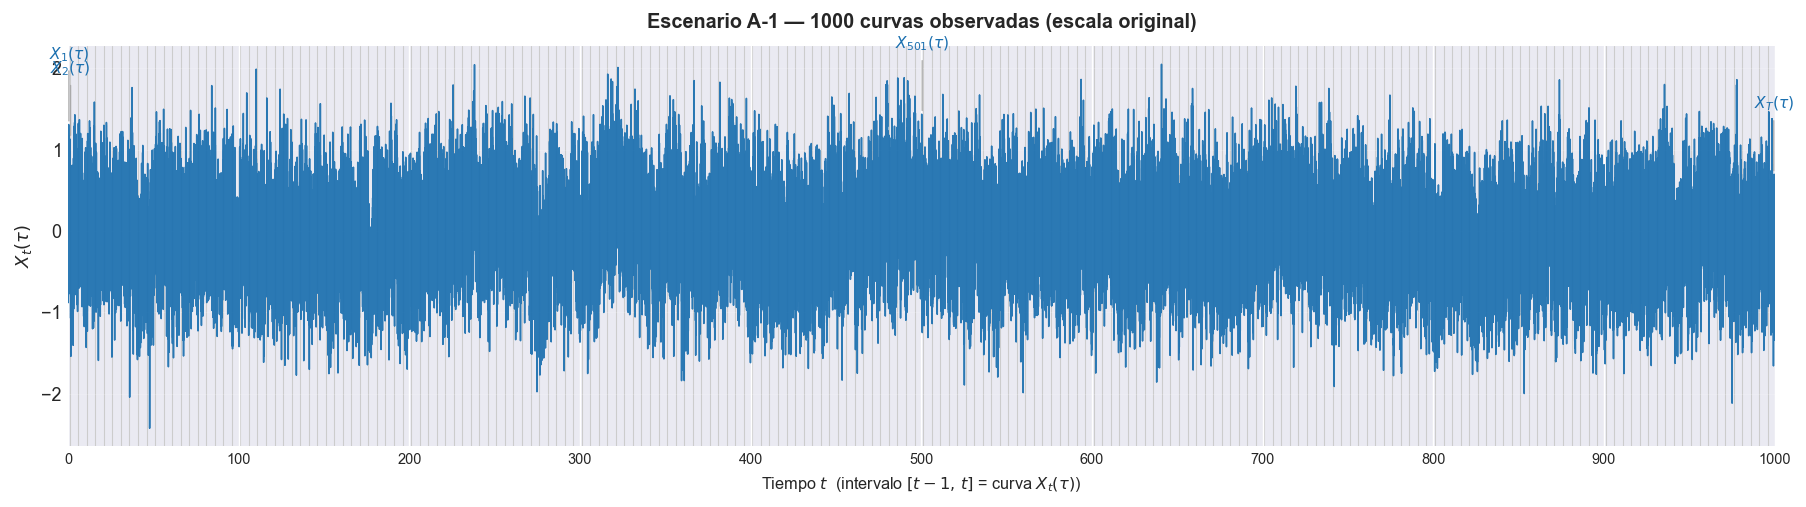

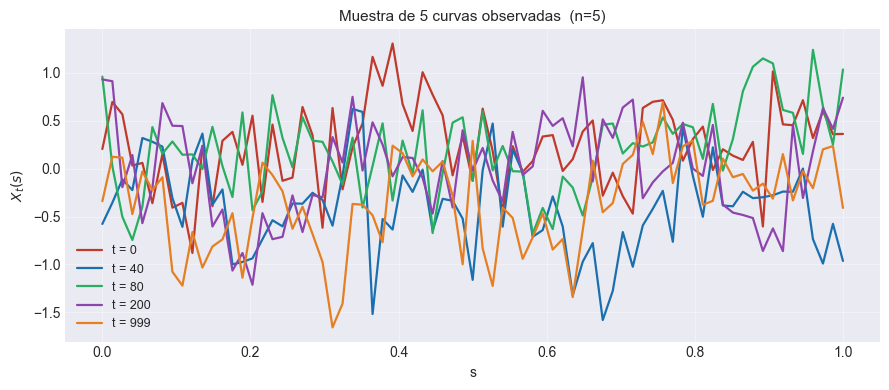

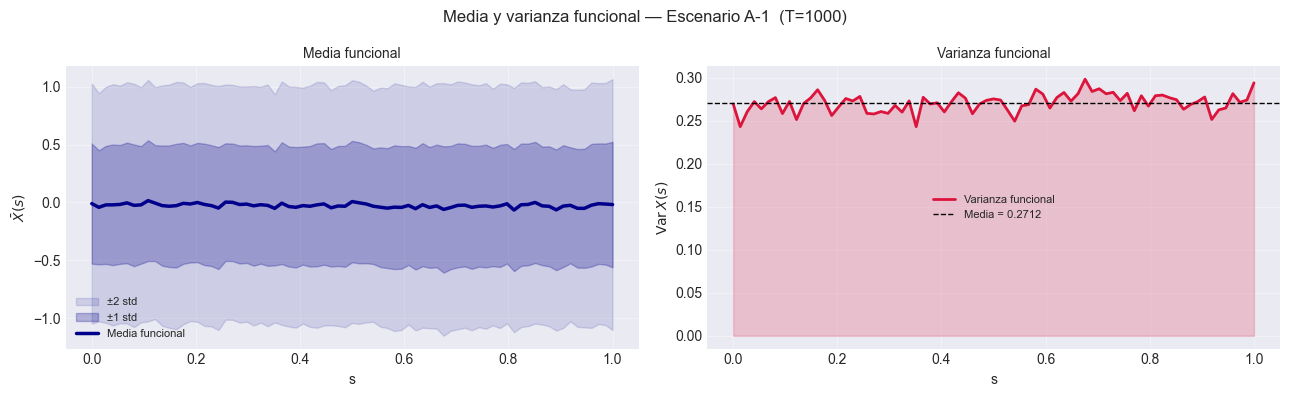

In [7]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario A-1 — {T} curvas observadas (escala original)")
replicar_figura("01_fts_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas")
replicar_figura("02_muestra_empirica_raw.png", PATHS_POR_M)
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — Escenario A-1")
replicar_figura("03_media_varianza_raw.png", PATHS_POR_M)
plt.show()

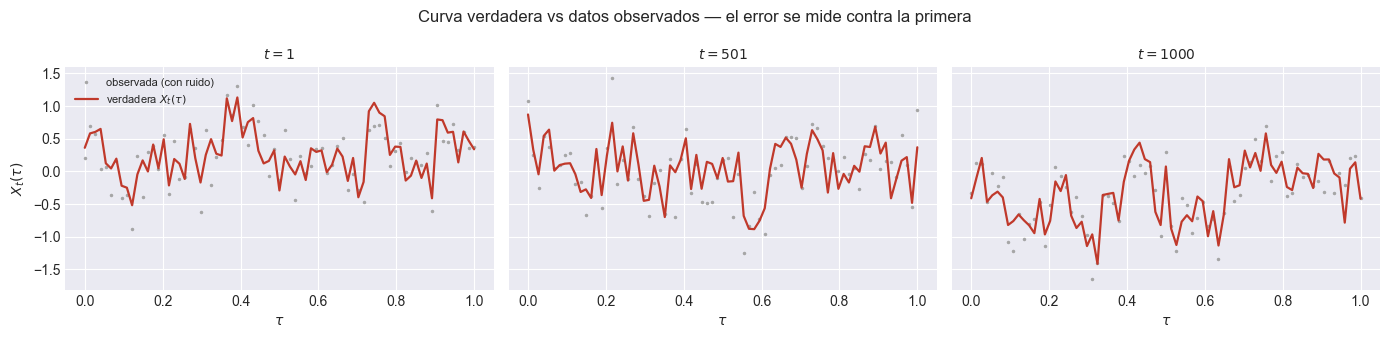

In [8]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
replicar_figura("04_curva_vs_datos.png", PATHS_POR_M, fig=fig)
plt.show()

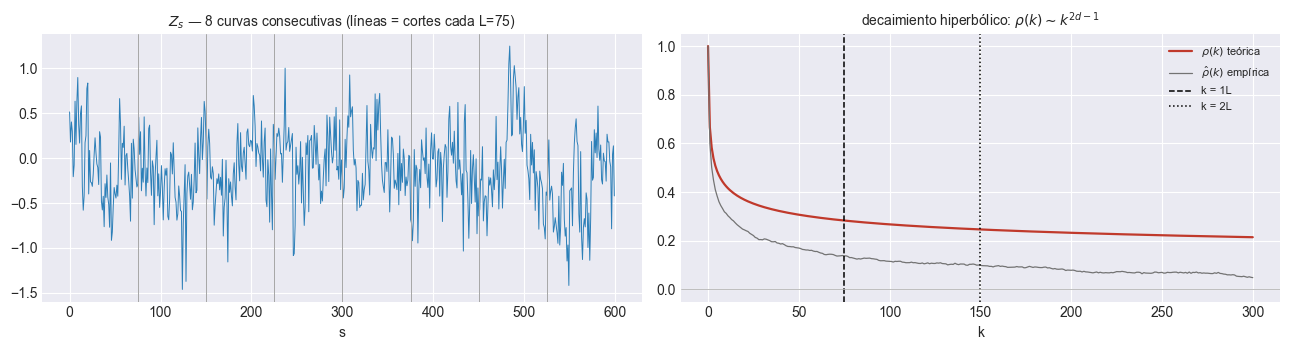

rho(L)  teórica 0.2831   empírica 0.1374
rho(2L) teórica 0.2465   empírica 0.0991
R^2 oráculo 1 rezago : teórico 0.2394  ·  medido 0.0976
R^2 pasado infinito  : 0.5169
||A_oráculo||_HS(L2) : 1.4345  ·  señal/ruido 3.33


In [9]:
Z_serie = salida.internos["serie_escalar"][REPLICA_IDX]
rho_teo = autocorrelacion_arfima(SIM_CFG.d, 4 * L_GRILLA)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
_n = 8 * L_GRILLA
axes[0].plot(np.arange(_n), Z_serie[-_n:], lw=0.7, color="#2c7fb8")
for _b in range(1, 8):
    axes[0].axvline(_b * L_GRILLA, color="0.65", lw=0.7)
axes[0].set_title(f"$Z_s$ — 8 curvas consecutivas (líneas = cortes cada L={L_GRILLA})",
                  fontsize=10)
axes[0].set_xlabel("s")

_z = Z_serie - Z_serie.mean()
_den = float((_z * _z).sum())
rho_emp = np.array([1.0] + [float((_z[:-k] * _z[k:]).sum() / _den)
                            for k in range(1, 4 * L_GRILLA + 1)])
axes[1].plot(rho_teo, lw=1.6, color="#c0392b", label=r"$\rho(k)$ teórica")
axes[1].plot(rho_emp, lw=0.9, color="0.45", label=r"$\hat\rho(k)$ empírica")
for _m, _st in ((1, "--"), (2, ":")):
    axes[1].axvline(_m * L_GRILLA, color="k", ls=_st, lw=1.1,
                    label=f"k = {_m}L")
axes[1].axhline(0, color="0.7", lw=0.6)
axes[1].set_title(r"decaimiento hiperbólico: $\rho(k)\sim k^{2d-1}$", fontsize=10)
axes[1].set_xlabel("k"); axes[1].legend(fontsize=8)
fig.tight_layout()
replicar_figura("04b_serie_escalar_acf.png", PATHS_POR_M, fig=fig)
plt.show()

print(f"rho(L)  teórica {salida.diagnostico['rho_teorica_lagL']:.4f}   "
      f"empírica {salida.diagnostico['rho_empirica_lagL']:.4f}")
print(f"rho(2L) teórica {salida.diagnostico['rho_teorica_lag2L']:.4f}   "
      f"empírica {salida.diagnostico['rho_empirica_lag2L']:.4f}")
print(f"R^2 oráculo 1 rezago : teórico "
      f"{salida.diagnostico['r2_oraculo_1rezago']:.4f}  ·  medido "
      f"{salida.diagnostico['r2_oraculo_1rezago_empirico']:.4f}")
print(f"R^2 pasado infinito  : "
      f"{salida.diagnostico['r2_oraculo_pasado_infinito_escalar']:.4f}")
print(f"||A_oráculo||_HS(L2) : {salida.diagnostico['hs_oraculo_L2']:.4f}  ·  "
      f"señal/ruido {salida.diagnostico['razon_senal_ruido']:.2f}")


### 2.4 Persistencia de curvas

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo.

In [10]:
_p = guardar_en_todos(guardar_curvas, PATHS_POR_M, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} -> {ruta.name}"
          f"   (replicado en {len(PATHS_POR_M)} directorios)")

[functional] curvas       -> X_curves.npy   (replicado en 8 directorios)
[functional] grilla       -> domain_grid.npy   (replicado en 8 directorios)
[functional] curvas_true  -> X_curves_true.npy   (replicado en 8 directorios)


### 2.5 Partición temporal

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador, que aquí queda en identidad— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`.

In [11]:
T0 = int(np.floor(PROP_TRAIN * T))
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"entrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

entrenamiento : t ∈ [1, 700]      → (700, 75)
prueba        : t ∈ [701, 1000]  → (300, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,27.7067%,0.442486,0.609658,0.208632
1,3,2,31.7139%,0.430274,0.583115,0.202580
2,4,2,34.7994%,0.420389,0.549833,0.198913
3,5,2,37.3472%,0.412165,0.525980,0.196641
4,6,2,39.7047%,0.404365,0.522884,0.194767
5,7,2,41.7001%,0.397576,0.515320,0.193901
6,8,2,43.4930%,0.391482,0.488986,0.193590
7,9,2,45.0439%,0.385986,0.494298,0.194025
8,10,2,46.5436%,0.380655,0.510598,0.194582
9,11,2,48.1831%,0.374792,0.477723,0.194554



GCV mínimo → n_basis=8, order=2  (var retenida 43.4930%)


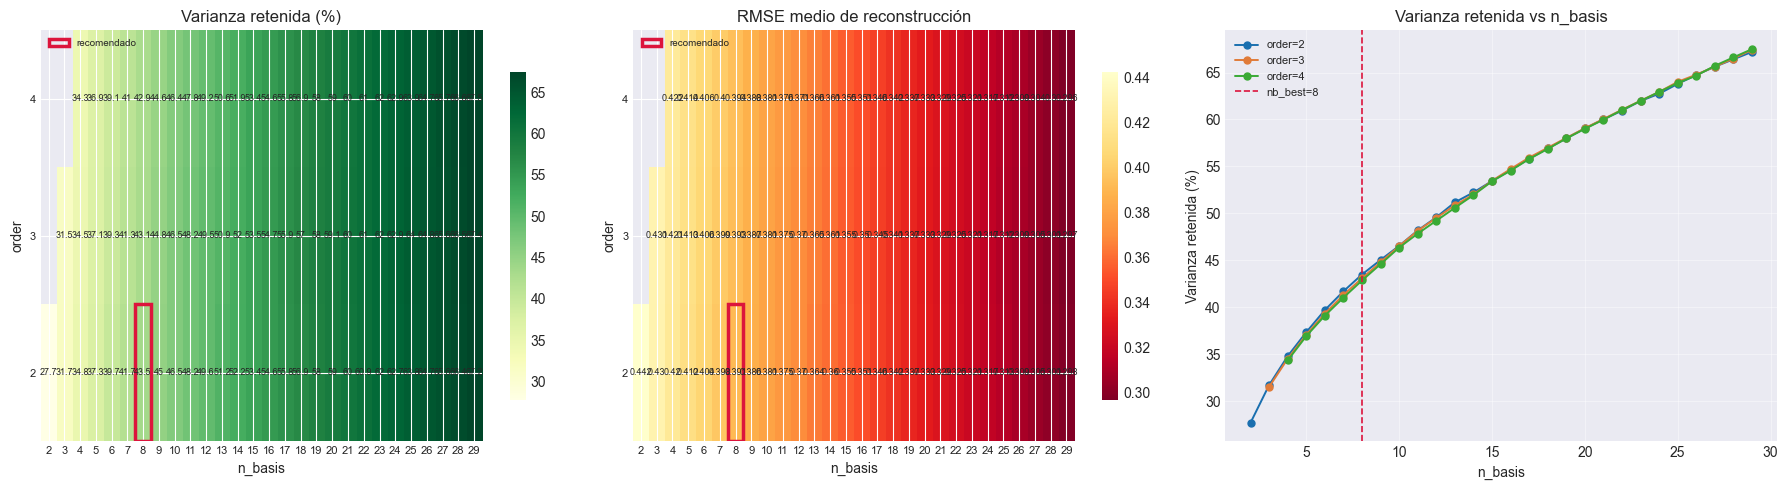

In [12]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best)
replicar_figura("05_seleccion_basis.png", PATHS_POR_M)
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=8, order=2
Sugerido GCV : n_basis=8, order=2   (coinciden)
THETA (1000, 8)  (train=700, test=300)
MISE(suavizada, observada) = 0.1542   ·   MISE(suavizada, verdadera) = 0.1050


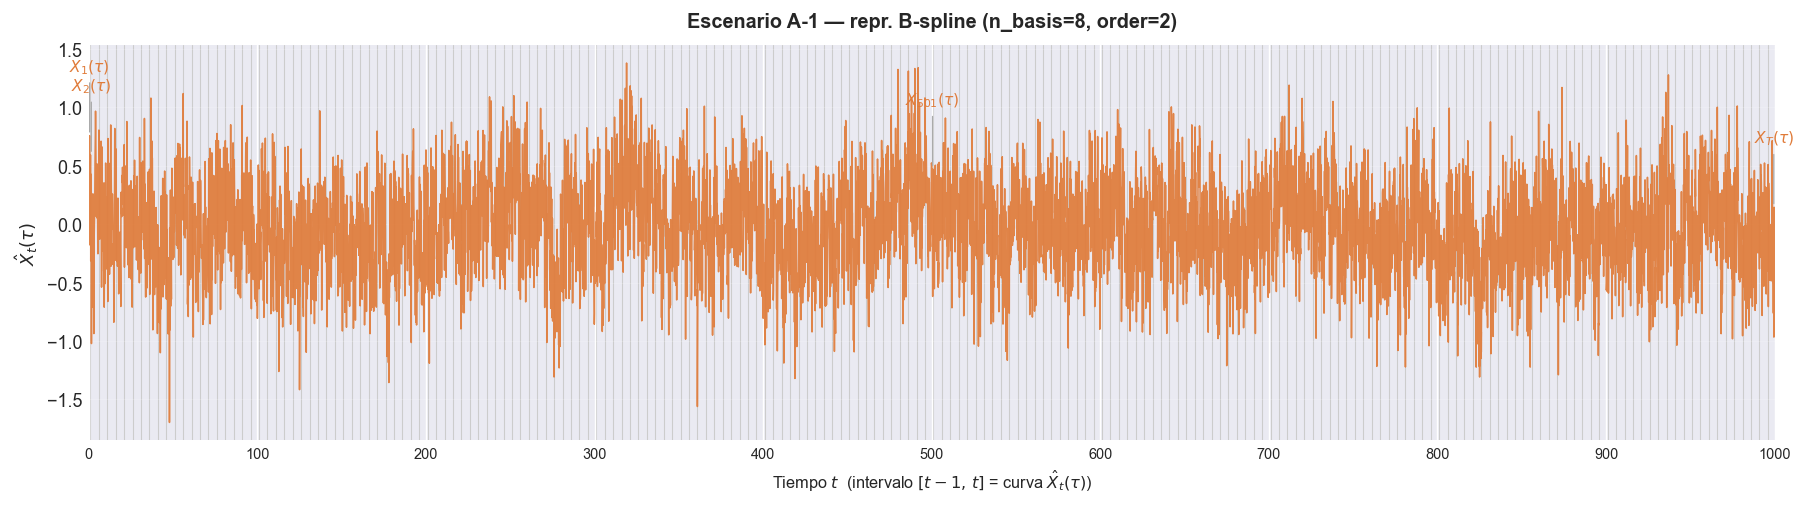

[functional] functional_representation.pkl + theta.csv + fr_config.json   (replicado en 8 directorios)


In [13]:
NB_ELEGIDO  = nb_best     # ← decisión del analista
ORD_ELEGIDO = ord_best

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE de la sugerencia; justificar en la tesis"))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
X_SUAV      = fr.reconstruct(THETA)           # objetivo de evaluacion (docs 03_05_00)
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")
print(f"MISE(suavizada, observada) = {float((((X_SUAV - X)**2).mean(1)).mean()):.4f}"
      f"   ·   MISE(suavizada, verdadera) = {float((((X_SUAV - X_true)**2).mean(1)).mean()):.4f}")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"Escenario A-1 — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})")
replicar_figura("06_fts_funcional_bspline.png", PATHS_POR_M)
plt.show()

guardar_en_todos(guardar_representacion, PATHS_POR_M, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print(f"[functional] functional_representation.pkl + theta.csv + fr_config.json"
      f"   (replicado en {len(PATHS_POR_M)} directorios)")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico



In [14]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

# cond(W) amplifica el ruido de las direcciones de menor autovalor, que son las
# que después se truncan. Se registra para comparar escenarios con distinto K.
cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 8
  K                                  = 8
  n_ajuste                           = 700
  cond_W                             = 3.894e+00
  err_ortonormalidad_L2              = 2.220e-15
  err_ortonormalidad_gram            = 2.109e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 4.441e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.427e-17
  err_media_scores_rel               = 1.045e-16
  err_var_scores_vs_lambda           = 4.857e-17
  err_var_scores_vs_lambda_rel       = 1.199e-15
  err_correlacion_lag0               = 9.995e-16
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

,componente,autovalor,var_ratio,var_acum,ar1_propio
0,1,6.0594e-02,50.5650%,50.5650%,+0.519
1,2,1.6773e-02,13.9970%,64.5620%,-0.167
2,3,1.1320e-02,9.4463%,74.0083%,+0.134
3,4,8.6826e-03,7.2456%,81.2539%,-0.058
4,5,6.9945e-03,5.8369%,87.0908%,+0.070
5,6,5.6475e-03,4.7128%,91.8036%,-0.058
6,7,4.9895e-03,4.1637%,95.9673%,-0.019
7,8,4.8325e-03,4.0327%,100.0000%,+0.044



K disponibles: 8   ·   sugerencia (var ≥ 95%): M = 7
  M=1: var. acum = 50.5650%  ·  sensibilidad
  M=2: var. acum = 64.5620%  ·  sensibilidad
  M=3: var. acum = 74.0083%  ·  sensibilidad
  M=4: var. acum = 81.2539%  ·  sensibilidad
  M=5: var. acum = 87.0908%  ·  sensibilidad
  M=6: var. acum = 91.8036%  ·  sensibilidad   <- cerca del techo K: componente en buena medida artefacto de una base corta
  M=7: var. acum = 95.9673%  ·  regla del 95 %   <- cerca del techo K: componente en buena medida artefacto de una base corta
  M=8: var. acum = 100.0000%  ·  sensibilidad   <- cerca del techo K: componente en buena medida artefacto de una base corta


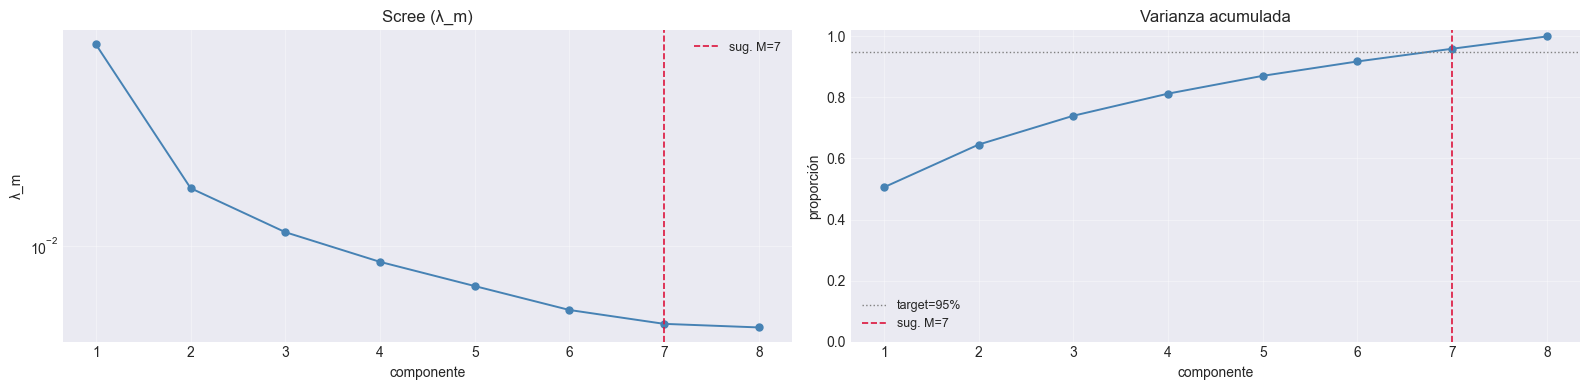

In [15]:
# Varianza ≠ dinámica: una FPC de varianza baja puede tener AR fuerte y ser útil
# para pronóstico, y una de varianza alta puede ser ruido temporal.
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

display(pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum, "ar1_propio": ar1,
}).head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1))

print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")

# K lo fija el GCV y ACOTA el barrido
assert max(M_FPCA_LIST) <= K, (
    f"M_FPCA_LIST={list(M_FPCA_LIST)} excede el K disponible: la base elegida "
    f"(n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}) da K = {K} componentes. "
    f"Reduzca el barrido o elija una base con más funciones en §3.2.")

_frontera = max(3, int(np.ceil(0.75 * K)))
for _M in M_FPCA_LIST:
    _marca = "regla del 95 %" if _M == M_SUGERIDO else "sensibilidad"
    _aviso = ("   <- cerca del techo K: componente en buena medida artefacto "
              "de una base corta" if _M >= _frontera else "")
    print(f"  M={_M}: var. acum = {fpca.var_cum[_M-1]:.4%}  ·  {_marca}{_aviso}")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET)
replicar_figura("07_fpca_scree.png", PATHS_POR_M)
plt.show()

### 3.4 Series de los componentes de la FPCA
- Se ven todos. 

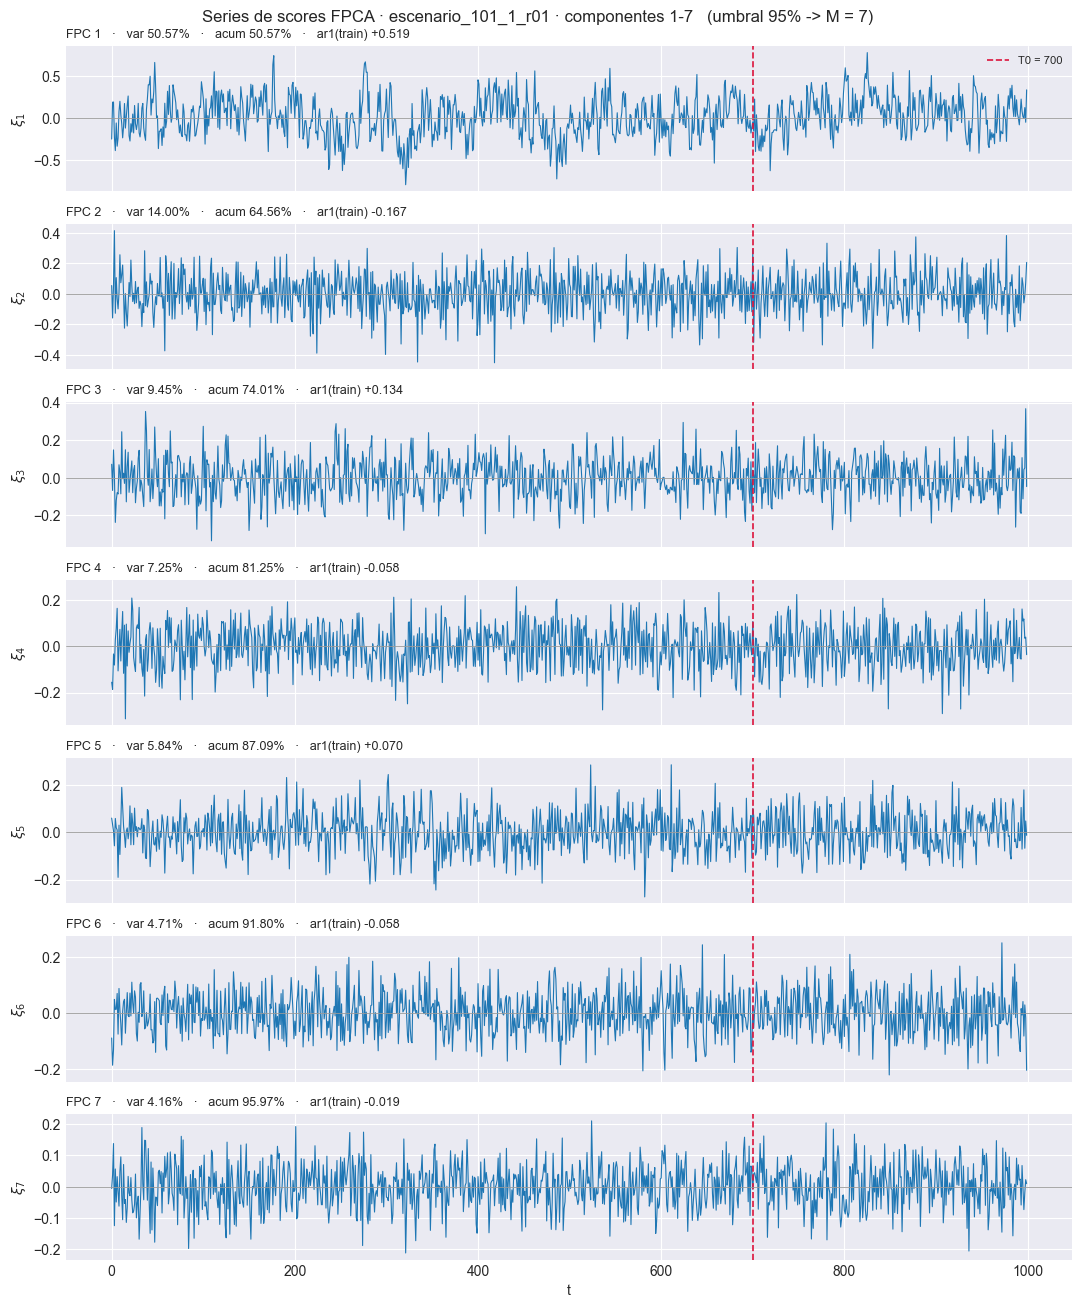

componentes graficadas : 1-7  de K = 8
var. acumulada hasta 7 : 95.9673%


In [16]:
# [CONFIG] §3.4 — hasta que componente se grafica. Por defecto, la que fija el
# umbral VAR_TARGET de la celda anterior; subirlo mira mas alla de la regla.
N_SERIES_SCORES = M_SUGERIDO

assert 1 <= N_SERIES_SCORES <= K, f"N_SERIES_SCORES={N_SERIES_SCORES} fuera de [1, {K}]."

# B_full y no B: no depende de set_M. Serie completa, no solo train.
XI = (THETA - fpca.mu_theta) @ (fpca.W @ fpca.B_full)      # (T, K)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI[:, k], lw=0.8, color="C0")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(rf"$\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   var {fpca.var_ratio[k]:.2%}   ·   "
                 f"acum {fpca.var_cum[k]:.2%}   ·   ar1(train) {ar1[k]:+.3f}",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Series de scores FPCA · {EXPERIMENT_BASE} · componentes 1-"
             f"{N_SERIES_SCORES}   (umbral {VAR_TARGET:.0%} -> M = {M_SUGERIDO})")
fig.tight_layout()
replicar_figura("07b_fpca_scores_series.png", PATHS_POR_M)
plt.show()

print(f"componentes graficadas : 1-{N_SERIES_SCORES}  de K = {K}"
      + ("" if N_SERIES_SCORES == M_SUGERIDO
         else f"   <- DIFIERE del umbral (M_SUGERIDO = {M_SUGERIDO})"))
print(f"var. acumulada hasta {N_SERIES_SCORES} : {fpca.var_cum[N_SERIES_SCORES-1]:.4%}")


### 3.5 Componentes estandarizados — sólo contraste

Los scores **no** se estandarizan: a MATLAB van los de §3.4, en su escala propia. Esta sección muestra lo que se descartó, no lo que se entrega.

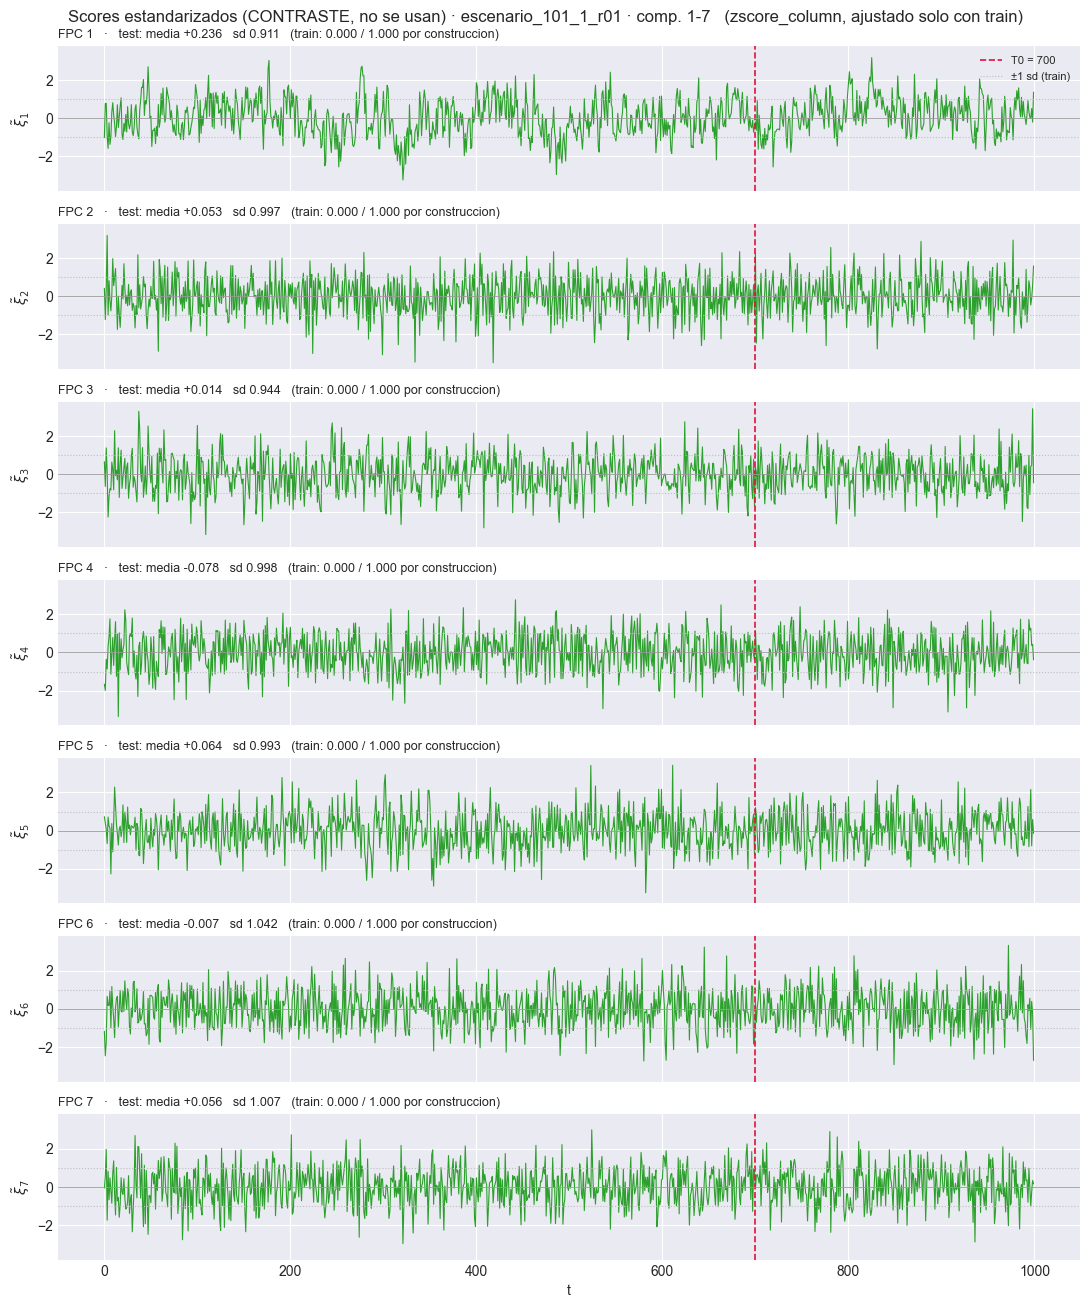

escala original  sd(train) : [0.246  0.1294 0.1063 0.0931 0.0836 0.0751 0.0706]
estandarizado    sd(test)  : [0.911  0.9967 0.9442 0.9979 0.9931 1.0421 1.0065]    <- lejos de 1 = el bloque de prueba no comparte escala con train


In [17]:
# §3.5 — mismo grafico que §3.4 pero estandarizando. CONTRASTE: NO es lo que
# se entrega. El pipeline usa los scores crudos; esto es la alternativa
# descartada, que se mira para saber cuanto cambia la escala.
_std = DataStandardizer(method="zscore_column", ddof=0)
_std.fit(XI[idx_train, :N_SERIES_SCORES], etiqueta=f"train[1:{T0}]")
XI_STD = _std.transform(XI[:, :N_SERIES_SCORES])            # (T, N_SERIES_SCORES)

fig, axes = plt.subplots(N_SERIES_SCORES, 1, sharex=True, sharey=True,
                         figsize=(11, 1.9 * N_SERIES_SCORES))
axes = np.atleast_1d(axes)
for k, ax in enumerate(axes):
    ax.plot(np.arange(T), XI_STD[:, k], lw=0.8, color="C2")
    ax.axvline(T0, color="crimson", ls="--", lw=1.2)
    ax.axhline(0, color="0.6", lw=0.6)
    for _s in (-1, 1):
        ax.axhline(_s, color="0.75", ls=":", lw=0.8)
    ax.set_ylabel(rf"$\tilde\xi_{{{k+1}}}$")
    ax.set_title(f"FPC {k+1}   ·   test: media {XI_STD[idx_test, k].mean():+.3f}   "
                 f"sd {XI_STD[idx_test, k].std():.3f}   "
                 f"(train: 0.000 / 1.000 por construccion)",
                 fontsize=9, loc="left")
axes[-1].set_xlabel("t")
axes[0].plot([], [], color="crimson", ls="--", lw=1.2, label=f"T0 = {T0}")
axes[0].plot([], [], color="0.75", ls=":", lw=0.8, label="±1 sd (train)")
axes[0].legend(loc="upper right", fontsize=8)

fig.suptitle(f"Scores estandarizados (CONTRASTE, no se usan) · {EXPERIMENT_BASE} · comp. 1-"
             f"{N_SERIES_SCORES}   (zscore_column, ajustado solo con train)")
fig.tight_layout()
plt.show()

print(f"escala original  sd(train) : "
      f"{np.array2string(XI[idx_train, :N_SERIES_SCORES].std(0), precision=4)}")
print(f"estandarizado    sd(test)  : "
      f"{np.array2string(XI_STD[idx_test].std(0), precision=4)}"
      "    <- lejos de 1 = el bloque de prueba no comparte escala con train")


## 4. El bucle sobre `M_FPCA_LIST`

Se realiza:
- §4.1:`set_M(M)` y scores; contraste con la regla del 95 % 
- §4.2: estandarizador en **identidad** (los scores van crudos) y artefactos FPCA 
- §4.3: diagnóstico de rezagos sobre el bloque de entrenamiento
- §4.4: orden AR y construcción de los datasets
- §4.5: hiperparámetros y `mcmc_config` — el contrato con MATLAB
- §4.6: `eval_config`, líneas base y `verificar_contrato` 


In [18]:
# E[tau] se declara como razon_Etau_lambda (= E[tau]*lambda_k, adimensional)
# o como e_tau_objetivo (literal, en 1/var(y)).
CLAVES_ETAU = ("razon_Etau_lambda", "e_tau_objetivo")


def clave_etau(escalera: dict) -> str:
    """La clave de E[tau] en uso, verificando que la escalera sea homogenea."""
    presentes = {c for pel in escalera.values() for c in CLAVES_ETAU if c in pel}
    if not presentes:
        raise KeyError(
            f"Ningun peldano de HP_ESCALERA declara E[tau]. Agrega una de "
            f"{CLAVES_ETAU} a cada uno.")
    if len(presentes) > 1:
        raise KeyError(
            f"HP_ESCALERA mezcla {sorted(presentes)}: los peldanos tienen que "
            "usar la MISMA convencion o los E[tau] no son comparables entre "
            "componentes.")
    clave = presentes.pop()
    faltan = [k for k, pel in escalera.items() if clave not in pel]
    if faltan:
        raise KeyError(f"Peldanos de HP_ESCALERA sin {clave!r}: {sorted(faltan)}.")
    return clave


def e_tau_del_peldano(esc: dict, var_y_k: float) -> float:
    """E[tau] del peldano, cualquiera sea la convencion con que se declaro."""
    if "razon_Etau_lambda" in esc:
        return float(esc["razon_Etau_lambda"]) / max(var_y_k, 1e-12)
    return float(esc["e_tau_objetivo"])


def procesar_punto(M: int) -> dict:
    """Produce TODOS los artefactos del punto M del barrido y verifica su contrato.

    Recibe por clausura los objetos comunes de §2-§3.3 —`fpca` ya ajustado,
    `THETA`, `idx_train`/`idx_test`, `grilla`, `X_true`— y no los recalcula:
    ésa es la garantía de que los puntos comparten realización y base.
    """
    PATHS = PATHS_POR_M[M]
    eid = experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M)
    print(f"\n{'='*70}\nM = {M}   ·   {eid}\n{'='*70}")

    # -- §4.1 Componentes retenidas ------------------------------------------
    assert 1 <= M <= fpca.evals.size, f"M fuera de [1, {fpca.evals.size}]."
    coincide_regla = (M == M_SUGERIDO)
    print(f"M(95 %) según la regla : {M_SUGERIDO}   (K disponible = {fpca.evals.size})")
    print(f"M de este punto        : {M}"
          + ("   (coincide con la regla)" if coincide_regla
             else "   <- DIFIERE de la regla: es un punto de sensibilidad"))

    fpca.set_M(int(M))
    M_fpca = fpca.M

    SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
    SCORES_train = SCORES[idx_train]
    SCORES_test  = SCORES[idx_test]

    print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
    print(f"[train] max|media xi| = {np.abs(SCORES_train.mean(0)).max():.2e}   (~ 0)")
    print(f"[test]  max|media xi| = {np.abs(SCORES_test.mean(0)).max():.3f}")
    print(f"[test]  var xi / lambda = "
          f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

    # -- §4.2 Escala de los scores: SIN estandarizar --------------------------
    # Se ajusta con train y se registra n_ajuste igual, porque verificar_contrato
    # exige n_ajuste == T0. Lo que NO se hace es aplicarlo: ver abajo.
    scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
    scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

    _chk = scores_standardizer.verificar_ajuste(T0)
    print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
          f"({_chk['etiqueta_ajuste']}) -> ok={_chk['ajuste_ok']}")

    # SIN ESTANDARIZAR MATLAB recibe los scores en su ESCALA PROPIA. El objeto
    # no se elimina
    MU_OBS = scores_standardizer.mean.copy()
    SD_OBS = scores_standardizer.std.copy()
    scores_standardizer.mean = np.zeros_like(MU_OBS)
    scores_standardizer.std  = np.ones_like(SD_OBS)

    SCORES_STD       = scores_standardizer.transform(SCORES)
    assert np.allclose(SCORES_STD, SCORES), "la transformacion deberia ser la identidad."
    SCORES_STD_train = SCORES_STD[idx_train]
    SCORES_STD_test  = SCORES_STD[idx_test]

    print(f"\nSCORES_STD {SCORES_STD.shape}   (= SCORES: transformacion identidad)")
    print(f"  [train] media = {np.array2string(MU_OBS, precision=3)}   <- NO se resta")
    print(f"  [train] std   = {np.array2string(SD_OBS, precision=3)}   <- NO se divide")
    print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
    print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
    print(f"  rango que vera MATLAB: [{SCORES_STD.min():.3f}, {SCORES_STD.max():.3f}]"
          "   <- de ahi sale la grilla G* y con ella la escala del gating")

    guardar_estandarizador(PATHS, scores_standardizer)
    _res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                        meta_extra={"T0": int(T0)})
    print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

    plot_diagnostico_estandarizacion(
        SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
        labels=("Scores xi (escala lambda)", "Scores xi entregados (identicos: no se estandariza)"),
        title=f"estadísticas por componente FPCA (M={M})",
        save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
    plt.show()

    # -- §4.3 Diagnóstico de rezagos (sólo train) ----------------------------

    N_LAGS_MAX = 3
    T_theta, K_total = SCORES_STD_train.shape

    def _spearman(Y, Xm):
        """Spearman columna a columna vía rangos (pandas, sin scipy)."""
        Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
        Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
        return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

    corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
    corr_s = np.zeros_like(corr_p)
    col_labels = []
    y_block = SCORES_STD_train[N_LAGS_MAX:, :]

    for lag in range(1, N_LAGS_MAX + 1):
        x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
        sp = _spearman(y_block, x_block)
        for j in range(K_total):
            c = (lag - 1) * K_total + j
            for k in range(K_total):
                corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
            corr_s[:, c] = sp[:, j]
            col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

    row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
    band = 1.96 / np.sqrt(len(y_block))

    for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
        plot_rezagos_heatmap(
            M_corr, col_labels, row_labels,
            title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}  (M={M})",
            n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
            save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
        plt.show()

    # -- §4.4 Orden AR y datasets --------------------------------------------
    COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

    n_components = len(COMPONENT_IDX)
    n_train_eff  = T0 - N_LAGS
    n_test_eff   = T - T0

    assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

    cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
                 for lag in range(1, N_LAGS + 1)
                 for j in range(n_components)]
    cov_por_comp = {k: [f"fpc_{COMPONENT_IDX[k] + 1}_lag{lag}"
                        for lag in range(1, N_LAGS + 1)]
                    for k in range(n_components)}

    print(f"componentes : {n_components} -> índices {COMPONENT_IDX}")
    print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_por_comp[0])} covariable(s) por componente (rezago propio)")
    print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
    print(f"cov_names   : {cov_names}")

    SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

    def _dataset_bloque(k, t_ini, t_fin):
        """Respuesta en t en [t_ini, t_fin) y predictores en t-1 ... t-N_LAGS."""
        t_idx  = np.arange(t_ini, t_fin)
        X_cols = np.column_stack([SCORES_sel[t_idx - lag, k] for lag in range(1, N_LAGS + 1)])
        return pd.DataFrame(np.column_stack([SCORES_sel[t_idx, k], X_cols]),
                            columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_por_comp[k])

    dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
    dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

    manifest = {
        "scores_scale":  "raw_fpca_scores",
        "n_components":  n_components,
        "n_lags":        int(N_LAGS),
        "component_idx": [int(i) for i in COMPONENT_IDX],
        "cov_names":     cov_names,
        "cov_por_componente": {str(k): cov_por_comp[k] for k in range(n_components)},
        "covariables":   "rezago_propio",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "ajuste_en": "train",
    }
    guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
    print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
    for k in range(n_components):
        print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

    # -- 4.5 Hiperparametros y MCMC
    # CALIBRACION DEL GATING, invariante de escala y de p.
    #
    #     v_h(x) = Phi( alpha_h - sum_j psi_hj |x_j - Gamma_hj| )
    #
    # Lo que hace que el gating DISCRIMINE no es la MEDIA de ese argumento sino
    # su DISPERSION a traves de i. alpha_h absorbe la media por construccion: su
    # condicional completa es la media de W = Z + sum_j psi|x - Gamma|
    # (psbp_train.m:209-211), de modo que un argumento grande pero constante en x
    # solo desplaza alpha y deja pi_h(x) plano. Calibrar sobre la media -lo que
    # hacia `arg_objetivo`- era calibrar sobre la cantidad equivocada.
    #
    # Medido en esta corrida, el CV de sum_j |x_j - Gamma_j| cae de 0.456 (p=1)
    # a 0.097 (p=8): al sumar coordenadas la media crece como p y la dispersion
    # solo como sqrt(p), asi que un `arg_objetivo` fijo apaga el gating justo al
    # subir en M. Con arg_objetivo=2 en M=8 el argumento tenia media 2.00 y
    # dispersion 0.19 -lo peor de los dos mundos: Phi saturado hacia 0, con la
    # mezcla colapsando en el ultimo atomo, y sin capacidad de distinguir x.
    #
    # Se calibra por COORDENADA y sobre la DISPERSION, dandole a cada covariable
    # un presupuesto sd_gate/sqrt(p) para que la dispersion TOTAL del argumento
    # sea sd_gate cualquiera sea p:
    #
    #     mupsij_j  = (sd_gate / sqrt(p)) / sd_i |x_ij - Gamma_hj|
    #     taupsij_j = 1 / (cv_psi * mupsij_j)^2        cv_psi = sd(psi)/E(psi)
    #
    # taupsij arrastraba el mismo defecto que `arg_objetivo` ya habia corregido
    # para mupsij, y nunca se arreglo: la informacion que los datos aportan sobre
    # psi es sum_i (x_ij - Gamma_hj)^2 (psbp_train.m:260), que escala con el
    # CUADRADO de la escala del score, mientras taupsij estaba fijo. Con scores
    # de sd ~ 0.25 el prior pesaba 23 % de la posterior de psi y lo dejaba pegado
    # a mupsij, o sea gating congelado. Atarlo a mupsij via cv_psi lo vuelve
    # invariante de escala y baja ese peso a ~5 %.
    #
    # mupsij y taupsij salen como VECTOR por covariable, que es como el .m ya los
    # lee (hp.mupsij(:), usado elemento a elemento en psijh(h,:)): NO hay cambio
    # en psbp_train.m ni en psbp_fd_iteracion.m.
    #
    # Se replica la grilla G* de psbp_train.m (min/max GLOBALES de Xnoint, no por
    # columna) y el sorteo de Gammajh sobre ella.
    _cal = []
    for _k in range(n_components):
        _Xk      = dfs_train[_k][cov_por_comp[_k]].to_numpy()
        _lo, _hi = float(_Xk.min()), float(_Xk.max())
        _Gstar   = _lo + (np.arange(1, MCMC_CONFIG["M"] + 1) / MCMC_CONFIG["M"]) * (_hi - _lo)
        _Gam     = np.random.default_rng(SEED + _k).choice(
            _Gstar, size=(MCMC_CONFIG["N"] - 1, _Xk.shape[1]))
        _D       = np.abs(_Xk[None, :, :] - _Gam[:, None, :])
        _cal.append({"Xk": _Xk, "Gstar": _Gstar,
                     "escala": float(_D.sum(-1).mean()),
                     "spread": _D.std(axis=1).mean(axis=0),
                     "media":  _D.mean(axis=(0, 1))})
        print(f"FPC {COMPONENT_IDX[_k] + 1}: G* = [{_lo:.3f}, {_hi:.3f}]   "
              f"sd_i|x - Gamma| = {np.array2string(_cal[-1]['spread'], precision=4)}")

    # Todas las covariables son rezagos PROPIOS de la componente; lo que las
    # ordena es el rezago, no k. El nombre es fpc_<idx>_lag<l>, asi que el tipo
    # sale de ahi y no de la posicion en la lista.
    def _clasificar(nombre, k_modelo):
        lag = int(nombre.rsplit("_lag", 1)[1])
        assert nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag{lag}", (
            f"{nombre} no es rezago propio de la componente {k_modelo}.")
        return f"own_lag{lag}"

    # apij/bpij salen de HP_BY_TYPE, no de la escalera: lo que los ordena es el
    # TIPO de rezago, no k. Lo demas de la escalera sigue siendo por componente.
    def _beta_pi(nombre, k_modelo):
        cfg = HP_BY_TYPE[_clasificar(nombre, k_modelo)]
        return float(cfg["apij"]), float(cfg["bpij"])

    # Tasa de escape del estado w_j = 0, que es ABSORBENTE: con w_j = 0 queda
    # pij = 0 (psbp_train.m:221) y entonces ajhin lleva log(realmin) ~ -708
    # (psbp_train.m:320), asi que ningun gamma_hj de los N atomos puede volver a
    # 1. La unica salida es la moneda de psbp_train.m:202, con probabilidad
    #     pwj * b_val / ((1-pwj) + pwj * b_val),
    #     b_val = B(apij, bpij+N) / B(apij, bpij)  ~  Gamma(a+b)/Gamma(b) N^-apij
    # que decae como N^(-apij): apij es el EXPONENTE. Con apij=bpij=5 y N=35 da
    # 1.2e-4, o sea 8600 iteraciones de espera sobre cadenas de 2500 -> w_j nunca
    # vuelve. Medido en la corrida 50_c: la mayoria de las covariables cruzadas
    # tienen UN solo flip y se quedan en cero hasta el final, y las dos cadenas
    # caen en iteraciones distintas -> R-hat de p_j hasta 2.94 con beta_j en
    # 1.000. Con apij = 1 se cierra en forma: escape = bpij/(bpij+N).
    def _escape(apij, bpij, pwj, N):
        b_val = math.exp(math.lgamma(bpij + N) + math.lgamma(apij + bpij)
                         - math.lgamma(bpij) - math.lgamma(apij + bpij + N))
        return pwj * b_val / ((1 - pwj) + pwj * b_val)

    HYPERPARAMS_LIST = []
    for k in range(n_components):
        esc       = HP_ESCALERA[k]
        # Presupuesto de dispersion por coordenada -> mupsij/taupsij VECTORES.
        mupsij_k  = (esc["sd_gate_objetivo"] / math.sqrt(len(cov_por_comp[k]))) / _cal[k]["spread"]
        taupsij_k = 1.0 / (esc["cv_psi"] * mupsij_k) ** 2
        _ab       = [_beta_pi(nm, k) for nm in cov_por_comp[k]]

        # btau se despeja de E[tau] y del atau del peldano: btau = atau / E[tau].
        # NO hay piso. tau_h es la precision residual DE CADA ATOMO, y la cota
        # var(residuo) <= var(y) sale de la ley de varianza total
        #     lambda_k = E_h[var(y|h)] + var_h(E[y|h])
        # que acota el PROMEDIO sobre la mezcla, no cada atomo: uno puede ser mas
        # disperso que la serie entera si otros son mas concentrados. Medido en
        # la corrida anterior, entre 8 % y 15 % de los atomos ocupados quedan por
        # debajo de 1/lambda_k, y la media de 1/tau_h dio 0.174 contra
        # lambda = 0.330, o sea el promedio SI respeta la cota.
        # 1/lambda_k se imprime como ESCALA de referencia -tau vive en unidades
        # de 1/var(y)- y por eso un E[tau] no se puede copiar de una corrida con
        # scores estandarizados, donde var(y) = 1. No es una restriccion.
        var_y_k = float(SCORES_train[:, k].var(ddof=0))
        E_tau_k = e_tau_del_peldano(esc, var_y_k)
        btau_k  = esc["atau"] / E_tau_k

        HYPERPARAMS_LIST.append({**HP_GLOBAL,
            "atau": float(esc["atau"]), "btau": float(btau_k),
            "apij":    np.array([a for a, _ in _ab], dtype=float),
            "bpij":    np.array([b for _, b in _ab], dtype=float),
            "mupsij":  np.asarray(mupsij_k,  dtype=float),
            "taupsij": np.asarray(taupsij_k, dtype=float)})

    print(f"\nN_CHAINS = {N_CHAINS} cadenas por componente "
          f"-> {N_CHAINS * n_components} jobs en MATLAB para este M")
    # razon = E[tau]*var(y); su inversa es la varianza residual del prior, en
    # unidades de var(y).
    def _aviso_etau(razon):
        frac = 1.0 / max(razon, 1e-12)      # varianza residual, en unidades de lambda_k
        if frac > 5.0:
            return (f"   <- el prior cree {frac:.0f}x la varianza del score: "
                    "banda ANCHA")
        if frac < 0.33:
            return (f"   <- el prior cree solo {frac:.2f} de la varianza: "
                    "riesgo de SUBCOBERTURA")
        return ""

    # `sd real` es la dispersion del argumento probit que efectivamente queda, y
    # es LA cifra a mirar: por debajo de ~0.3 el gating no discrimina. `media
    # arg` es con las p coordenadas encendidas; gamma_hj apaga la mayoria de los
    # cruzados (E[pi] = 1/6) y psi_hj := 0 cuando gamma_hj = 0
    # (psbp_train.m:254), asi que la media realizada es bastante menor.
    print(f"  {'k':>2} {'fpc':>4} {'sd_gate':>8} {'sd real':>8} {'media arg':>10} "
          f"{'cv_psi':>7} {'Etau*lam':>9} {'var(y)':>9} {'E[tau]':>8} {'btau':>9}")
    for k in range(n_components):
        hp, esc = HYPERPARAMS_LIST[k], HP_ESCALERA[k]
        _v    = float(SCORES_train[:, k].var(ddof=0))
        _sd   = float(np.sqrt(((hp["mupsij"] * _cal[k]["spread"]) ** 2).sum()))
        _med  = float((hp["mupsij"] * _cal[k]["media"]).sum())
        _flag = "   <- gating DEBIL" if _sd < 0.3 else ""
        print(f"  {k:>2} {COMPONENT_IDX[k]+1:>4} {esc['sd_gate_objetivo']:>8.2f} "
              f"{_sd:>8.2f} {_med:>10.2f} {esc['cv_psi']:>7.2f} "
              f"{(hp['atau'] / hp['btau']) * _v:>9.2f} {_v:>9.5f} "
              f"{hp['atau']/hp['btau']:>8.2f} {hp['btau']:>9.5f}"
              + _aviso_etau((hp['atau'] / hp['btau']) * _v) + _flag)

    # Peso del prior sobre psi: taupsij / (taupsij + sum_i (x_ij - Gamma_hj)^2).
    # Es el diagnostico de si psi puede moverse o quedo clavado en mupsij.
    _peso = []
    for k in range(n_components):
        _kh   = _cal[k]["Xk"].shape[0] / MCMC_CONFIG["N"]
        _info = _kh * ((_cal[k]["Xk"] - _cal[k]["Gstar"][len(_cal[k]["Gstar"]) // 2]) ** 2).mean(axis=0)
        _peso.append(float(np.mean(HYPERPARAMS_LIST[k]["taupsij"]
                                   / (HYPERPARAMS_LIST[k]["taupsij"] + _info))))
    _peso = np.array(_peso)
    print(f"\npeso del prior sobre psi por componente = "
          f"{np.array2string(_peso * 100, precision=1)} %"
          "   (>30 % = psi clavado en mupsij, gating congelado)")

    # apij/bpij por covariable + la espera esperada para que w_j vuelva de 0.
    print(f"\n  {'k':>2} {'covariable':>16} {'tipo':>10} {'apij':>6} {'bpij':>6} "
          f"{'E[pi]':>7} {'P(escape)':>10} {'espera':>8}")
    for k in range(n_components):
        hp = HYPERPARAMS_LIST[k]
        for j, nm in enumerate(cov_por_comp[k]):
            a, b = hp["apij"][j], hp["bpij"][j]
            pe   = _escape(a, b, HP_GLOBAL["pwj"], MCMC_CONFIG["N"])
            flag = "  <- > nsim" if 1 / pe > MCMC_CONFIG["nsim"] else ""
            print(f"  {k:>2} {nm:>16} {_clasificar(nm, k):>10} {a:>6.3f} {b:>6.3f} "
                  f"{a/(a+b):>7.3f} {pe:>10.2e} {1/pe:>8.0f}{flag}")

    hp_artifact = {
        "global":       HP_GLOBAL,
        "by_type":      HP_BY_TYPE,
        "escalera":     {str(k): HP_ESCALERA[k] for k in range(n_components)},
        "escala_probit": [c["escala"] for c in _cal],
        "mcmc_config":  MCMC_CONFIG,
        "n_iter":       N_CHAINS,
        "seed_scheme":  "seed_base + chain*9973 + k*31",
        "escenario_id": int(ESCENARIO_ID),
        "replica_id":   int(REPLICA_ID),
        "m_fpca":       int(M),
        "m_entrenamiento": int(M_ENTRENO),
        "trazas_en":    experiment_id(BASENAME, ESCENARIO_ID, REPLICA_ID, M_ENTRENO),
        "covariables":  "rezago_propio",
        "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
        "scores_scale": "raw_fpca_scores",
        "partition": {
            "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
            "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
            "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                            for k in range(n_components)],
            "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                            for k in range(n_components)],
        },
        "hyperparams_list": [
            {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
             "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                             for key, v in HYPERPARAMS_LIST[k].items()}}
            for k in range(n_components)
        ],
    }
    guardar_hiperparametros(PATHS, hp_artifact)
    print(f"[out_artefact] hyperparameters.json -> {PATHS['out_artefact']}")

    # -- §4.6 Evaluación, líneas base y contrato -----------------------------
    eval_config = {
        "scheme":      "holdout_temporal",
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "horizons":    [1],
        "n_lags":      int(N_LAGS),
        "m_fpca":      int(M),
        "scores_scale": "raw_fpca_scores",
        # Contra QUE se mide el error (docs 03_05_00). Ninguno es la grilla cruda.
        #   principal  : curva suavizada = representacion B-spline de la observada
        #   secundario : X_t^(M), la expansion truncada; solo metodos sobre scores
        "objetivo_evaluacion": "curva_suavizada",
        "objetivo_secundario": "representacion_fpca",
        # Forzado por el modelo, no es perilla: la variabilidad vive en la mezcla.
        "modo_residuo":        "ninguno",
        "nivel_credibilidad":  0.95,
        "ventana_movil": {"w": [20, 30, 40], "paso": 1, "solapadas": True},
        # Las metricas del marco teorico 02_02_03, y solo esas.
        "metricas_bloque_A": ["mae_f", "rmse_f", "linf_medio", "linf_max"],
        "metricas_bloque_B": ["mpiw", "picp", "picp_simultaneo", "winkler",
                              "winkler_max_medio", "winkler_max_glob"],
    }
    guardar_config_evaluacion(PATHS, eval_config)
    print("[out_artefact] eval_config.json")

    # Líneas base a h=1: el piso que el PSBP-FD debe superar.
    baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                                   fpca=fpca, X_obs=X_SUAV, tau=grilla, h=1)
    baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
    display(baselines_df.style.format("{:.4f}", na_rep="-")
            .set_caption(f"Líneas base (M={M}) — prueba, h=1, contra la curva SUAVIZADA"))

    informe = verificar_contrato(PATHS)
    print(f"contrato_ok = {informe['contrato_ok']}   "
          f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
          f"n_components={informe['n_components']})")
    print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas "
          f"(T0={informe['T0']})")
    print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
    if not informe["contrato_ok"]:
        print("\nPROBLEMAS:")
        for p in informe.get("problemas", []):
            print(f"  - {p}")

    return {
        "M": int(M),
        "experiment_id": eid,
        "var_acum": float(fpca.var_cum[M_fpca - 1]),
        "K": int(fpca.evals.size),
        "coincide_regla_95": bool(coincide_regla),
        "n_components": int(n_components),
        "p_covariables": int(len(cov_por_comp[0])),
        "contrato_ok": bool(informe["contrato_ok"]),
        "problemas": informe.get("problemas", []),
    }

HP_BY_TYPE = apij=1, bpij=5 (Chung & Dunson original) para las 4  ·  N=30  escape=0.125 (espera~8 iter)  E[pi]=0.167

escalera por componente (btau se despeja en procesar_punto):
   k  sd_gate  cv_psi   atau  razon_Etau_lambda
   0     0.80    1.00   2.50               2.50
   1     0.80    1.00   2.00               2.50
   2     0.80    1.00   0.50               1.50
   3     0.80    1.00   0.50               1.50
   4     0.80    1.00   0.50               1.50
   5     0.80    1.00   0.50               1.50
   6     0.80    1.00   0.50               1.50
   7     0.80    1.00   0.50               1.50
  (mupsij y taupsij ya no se fijan aqui: se despejan por covariable en procesar_punto)

inclusion por tipo (apij/bpij ya no son de la escalera):
    own_lag1  apij=1.0000  bpij=5.0000  E[pi]=0.167
    own_lag2  apij=1.0000  bpij=5.0000  E[pi]=0.167
    own_lag3  apij=1.0000  bpij=5.0000  E[pi]=0.167
    own_lag4  apij=1.0000  bpij=5.0000  E[pi]=0.167
N_LAGS      : 4
MCMC_CONFIG : {'nsim

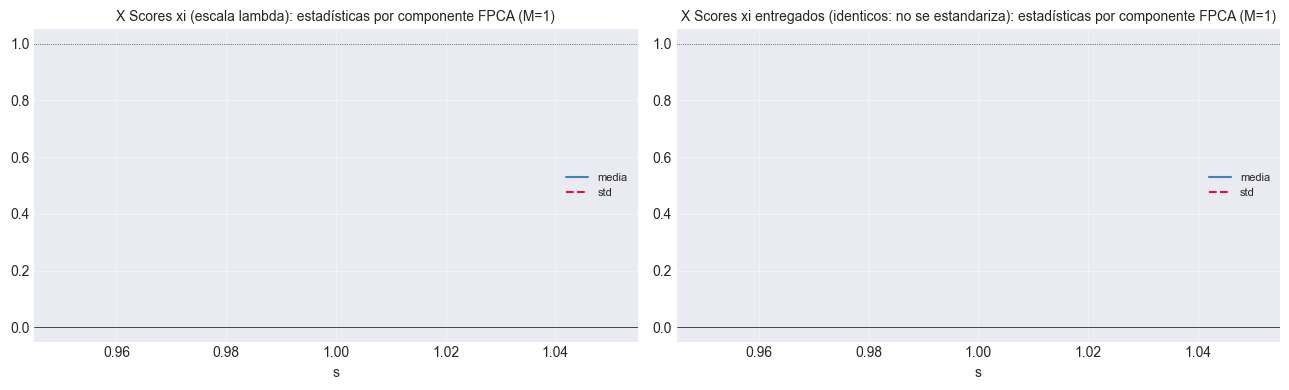

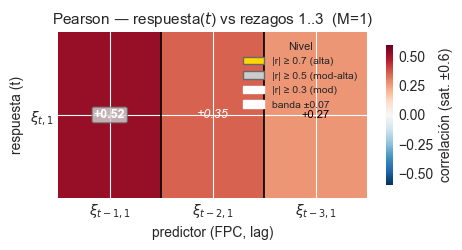

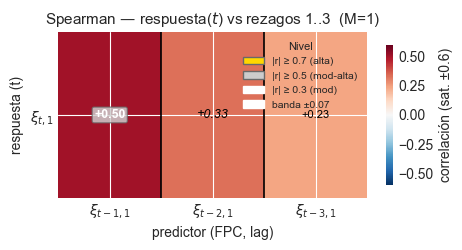

componentes : 1 -> índices [0]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_1_lag2', 'fpc_1_lag3', 'fpc_1_lag4']
[functional] 2 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]

N_CHAINS = 2 cadenas por componente -> 2 jobs en MATLAB para este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     0.80     0.80       3.38    1.00      2.50   0.06051    41.32   0.06051

peso del prior sobre psi por componente = [17.5] %   (>30 % = psi clavado en mupsij, gating congelado)

   k       covariable       tipo   apij   bpij   E[pi]  P(escape)   espera
   0       fpc_1_lag1   own_lag1  1.000  5.000   0.167   1.25e-01        8
   0       fpc_1_lag2   own_lag2  1.000  5.000   0.167   1.25e-01        8
   0       fpc_1_lag3   own_lag3  1.000  5.000   0

,n_test,RMSE_fpc1,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,
media_incondicional,300.0000,0.2315,0.2315,-0.0669,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.2269,-0.0255,0.1101,0.3319


contrato_ok = True   (M=1, K=8, T0=700, n_components=1)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 2   ·   escenario_101_1_r01_m02
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 2   <- DIFIERE de la regla: es un punto de sensibilidad
M = 2   var. explicada = 64.5620%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 2)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18]   <- NO se resta
  [train] std   = [0.246 0.129]   <- NO se divide
  [test]  media = [0.058 0.007]
  [test]  std   = [0.224 0.129]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 3.894e+00


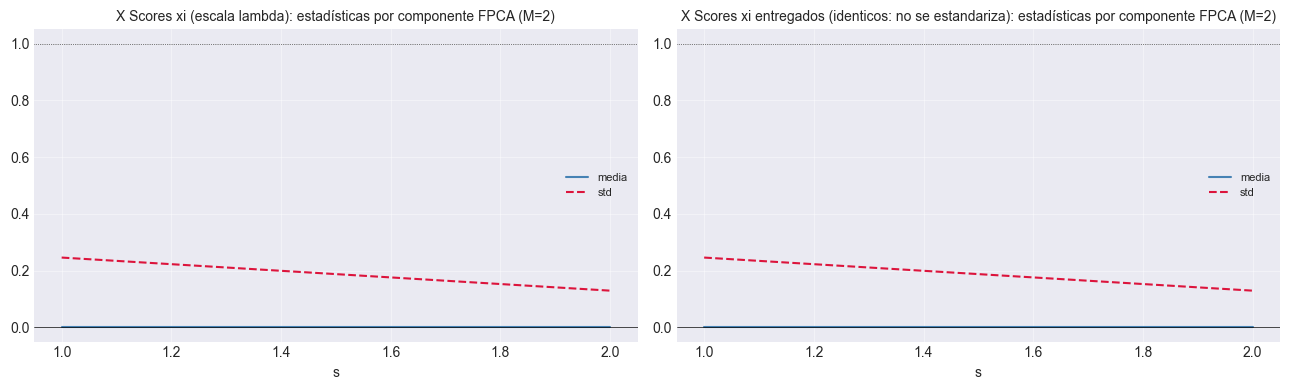

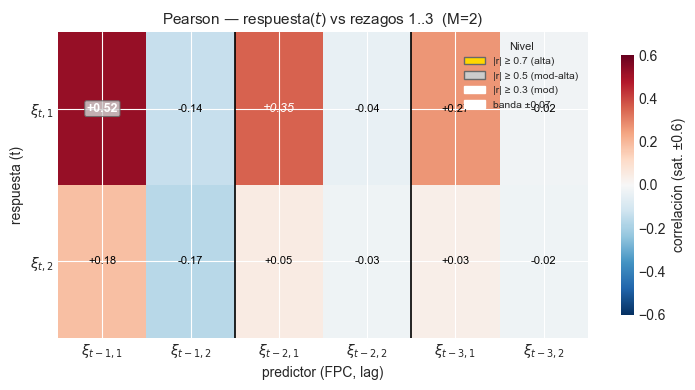

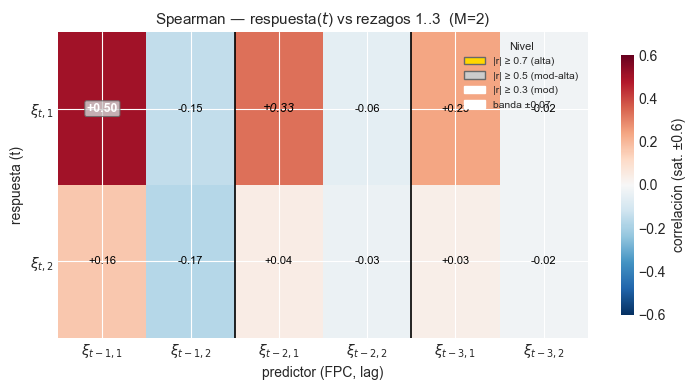

componentes : 2 -> índices [0, 1]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_1_lag4', 'fpc_2_lag4']
[functional] 4 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415]   sd_i|x - Gamma| = [0.1087 0.1121 0.1141 0.1124]

N_CHAINS = 2 cadenas por componente -> 4 jobs en MATLAB para este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     0.80     0.80       3.38    1.00      2.50   0.06051    41.32   0.06051
   1    2     0.80     0.80       3.37    1.00      2.50   0.01675   149.26   0.01340

peso del prior sobre psi por componente = [17.5 16.7] %   (>30 % = psi clavado en mupsij, gating congelado)

   k   

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1803,-0.0348,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.2087,-0.6029,0.1297,0.3602


contrato_ok = True   (M=2, K=8, T0=700, n_components=2)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 3   ·   escenario_101_1_r01_m03
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 3   <- DIFIERE de la regla: es un punto de sensibilidad
M = 3   var. explicada = 74.0083%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 3)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106]   <- NO se divide
  [test]  media = [0.058 0.007 0.001]
  [test]  std   = [0.224 0.129 0.1  ]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 3.894e+00


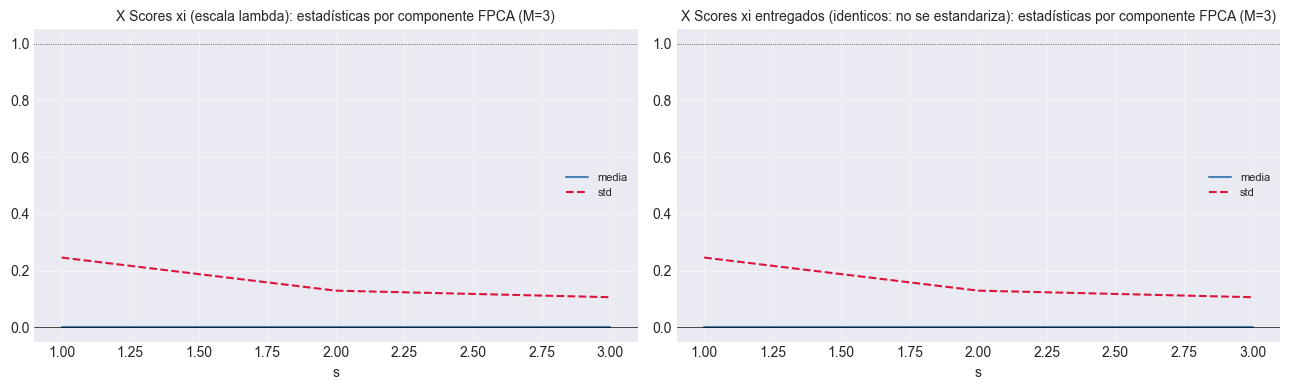

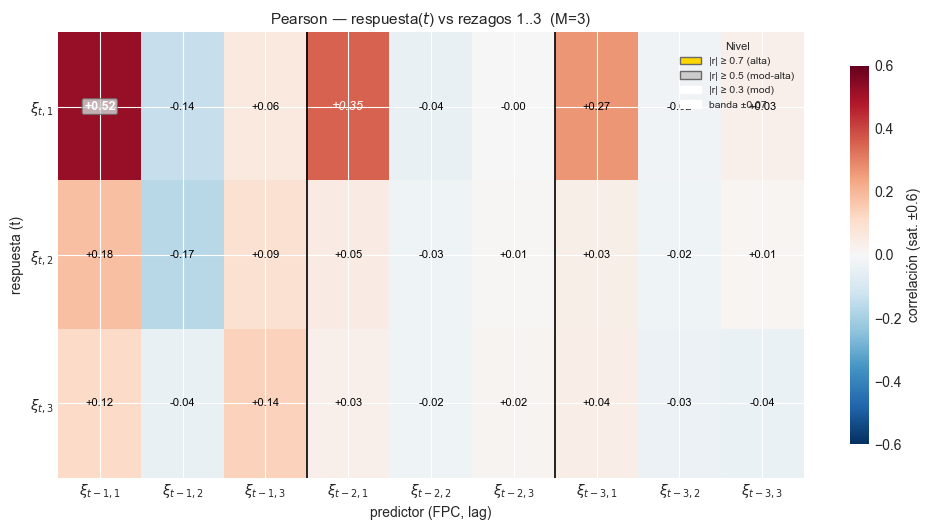

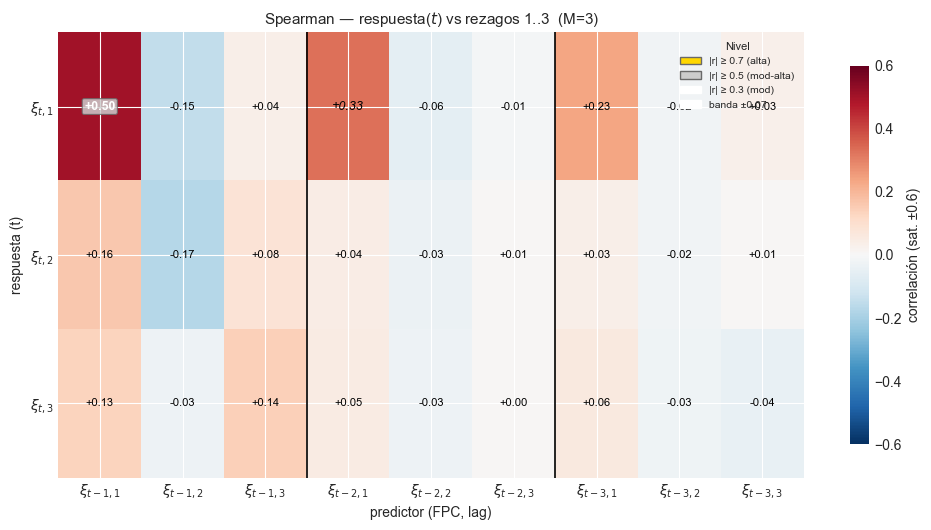

componentes : 3 -> índices [0, 1, 2]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4']
[functional] 6 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415]   sd_i|x - Gamma| = [0.1087 0.1121 0.1141 0.1124]
FPC 3: G* = [-0.336, 0.353]   sd_i|x - Gamma| = [0.0907 0.0899 0.0922 0.0944]

N_CHAINS = 2 cadenas por componente -> 6 jobs en MATLAB para este M
   k  fpc  sd_gate  sd real  media arg  cv_psi  Etau*lam    var(y)   E[tau]      btau
   0    1     0.80     0.80       3.38    1.00      2.50   0.06051    41.32   0.06051
   1    2     0.80     0.8

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.1537,-0.0233,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1860,-0.7219,0.1394,0.3734


contrato_ok = True   (M=3, K=8, T0=700, n_components=3)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 4   ·   escenario_101_1_r01_m04
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 4   <- DIFIERE de la regla: es un punto de sensibilidad
M = 4   var. explicada = 81.2539%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893 0.998]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 4)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18  9.734e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106 0.093]   <- NO se divide
  [test]  media = [ 0.058  0.007  0.001 -0.007]
  [test]  std   = [0.224 0.129 0.1   0.093]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 3.894e+00


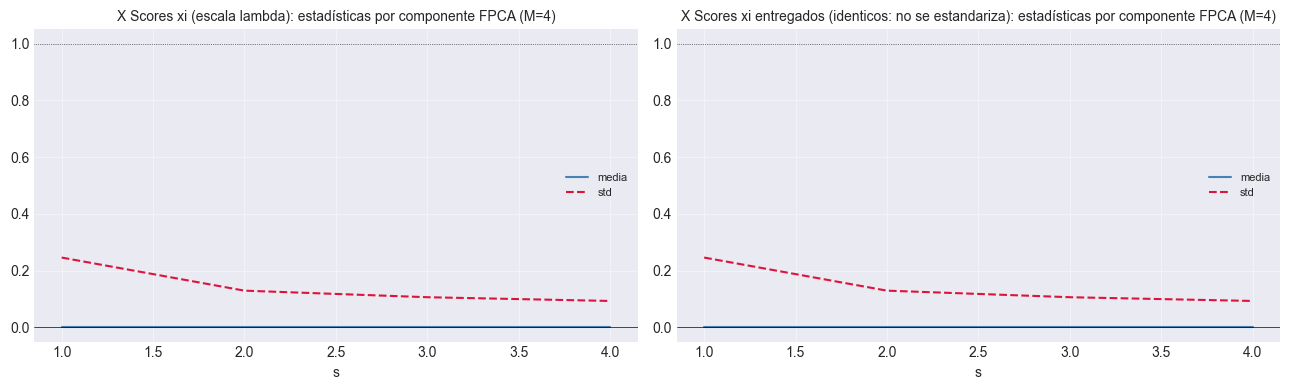

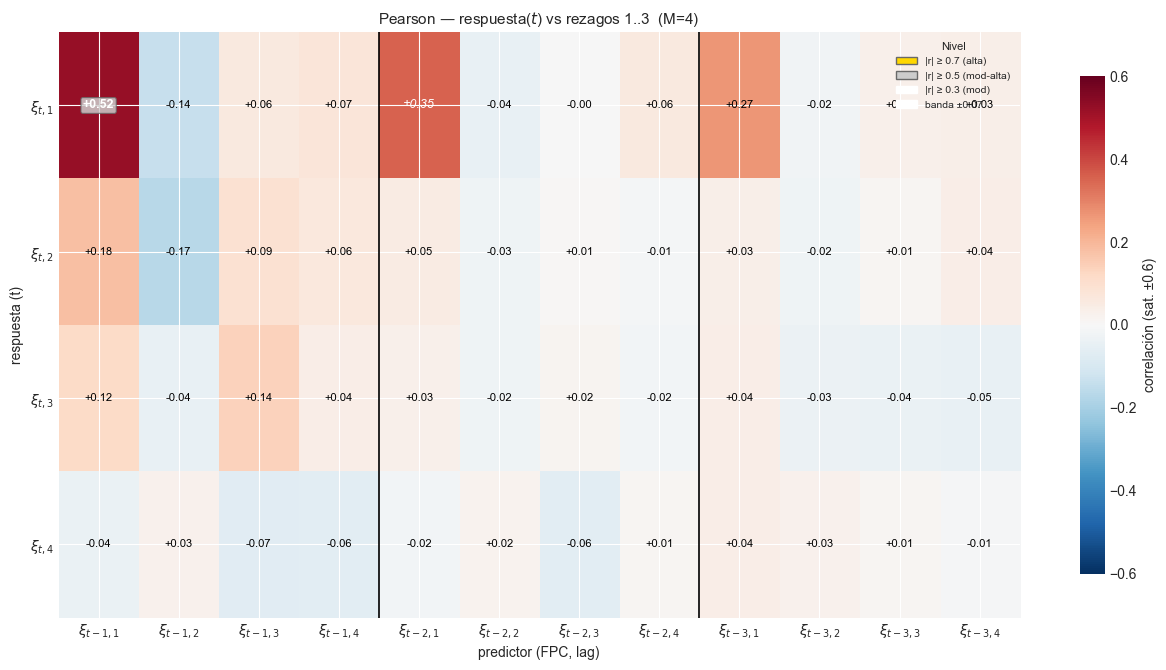

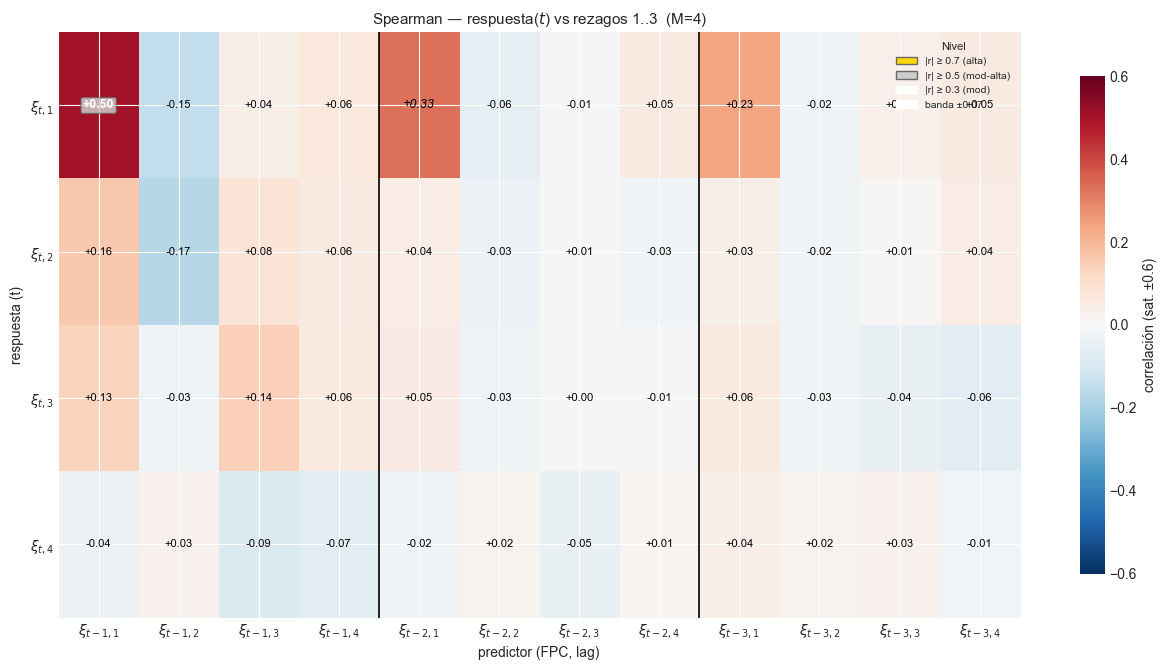

componentes : 4 -> índices [0, 1, 2, 3]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4']
[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415]   sd_i|x - Gamma| = [0.1087 0.1121 0.1141 0.1124]
FPC 3: G* = [-0.336, 0.353]   sd_i|x - Gamma| = [0.0907 0.0899 0.0922 0.0944]
FPC 4: G* = [-0.314, 0.258]   sd_i|x - Gamma| = [0.0822 0.079  0.0775 0.08  ]

N_CHAINS = 2 cadenas por componente -> 8 jobs en MATLAB para este M
   k  fpc  sd_gate  s

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.0932,0.1386,-0.0190,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1384,0.1741,-0.8458,0.1499,0.3871


contrato_ok = True   (M=4, K=8, T0=700, n_components=4)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 5   ·   escenario_101_1_r01_m05
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 5   <- DIFIERE de la regla: es un punto de sensibilidad
M = 5   var. explicada = 87.0908%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893 0.998 0.988]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 5)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18  9.734e-18 -5.016e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106 0.093 0.084]   <- NO se divide
  [test]  media = [ 0.058  0.007  0.001 -0.007  0.005]
  [test]  std   = [0.224 0.129 0.1   0.093 0.083]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gating

[functional] artefactos FPCA · cond_W = 

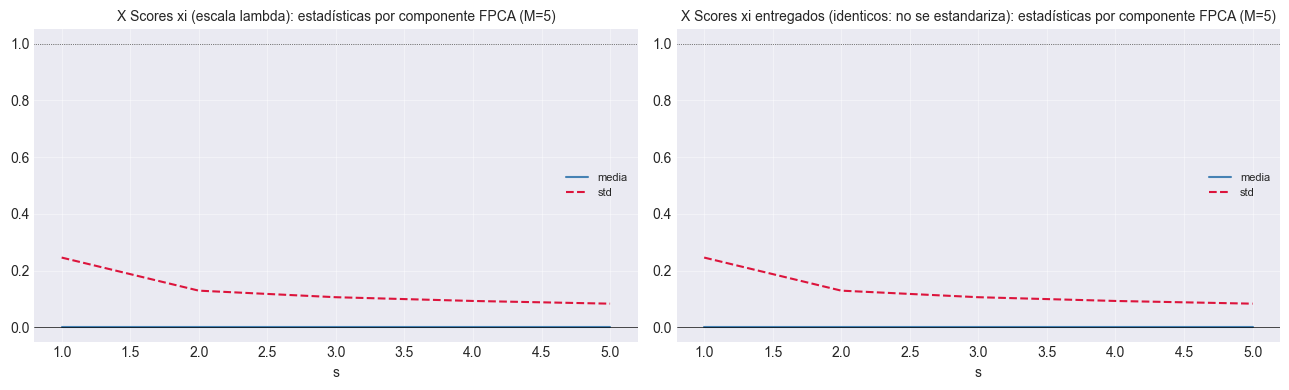

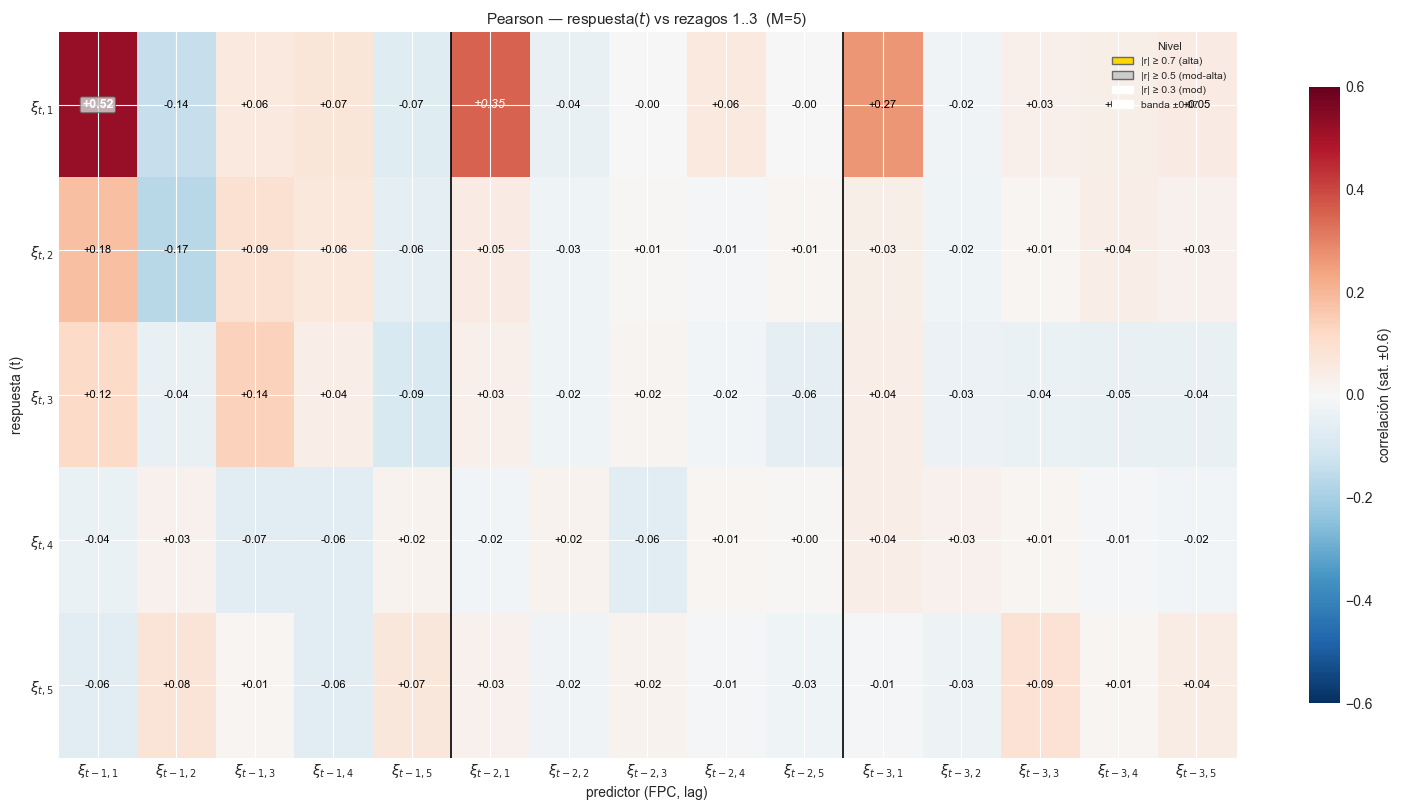

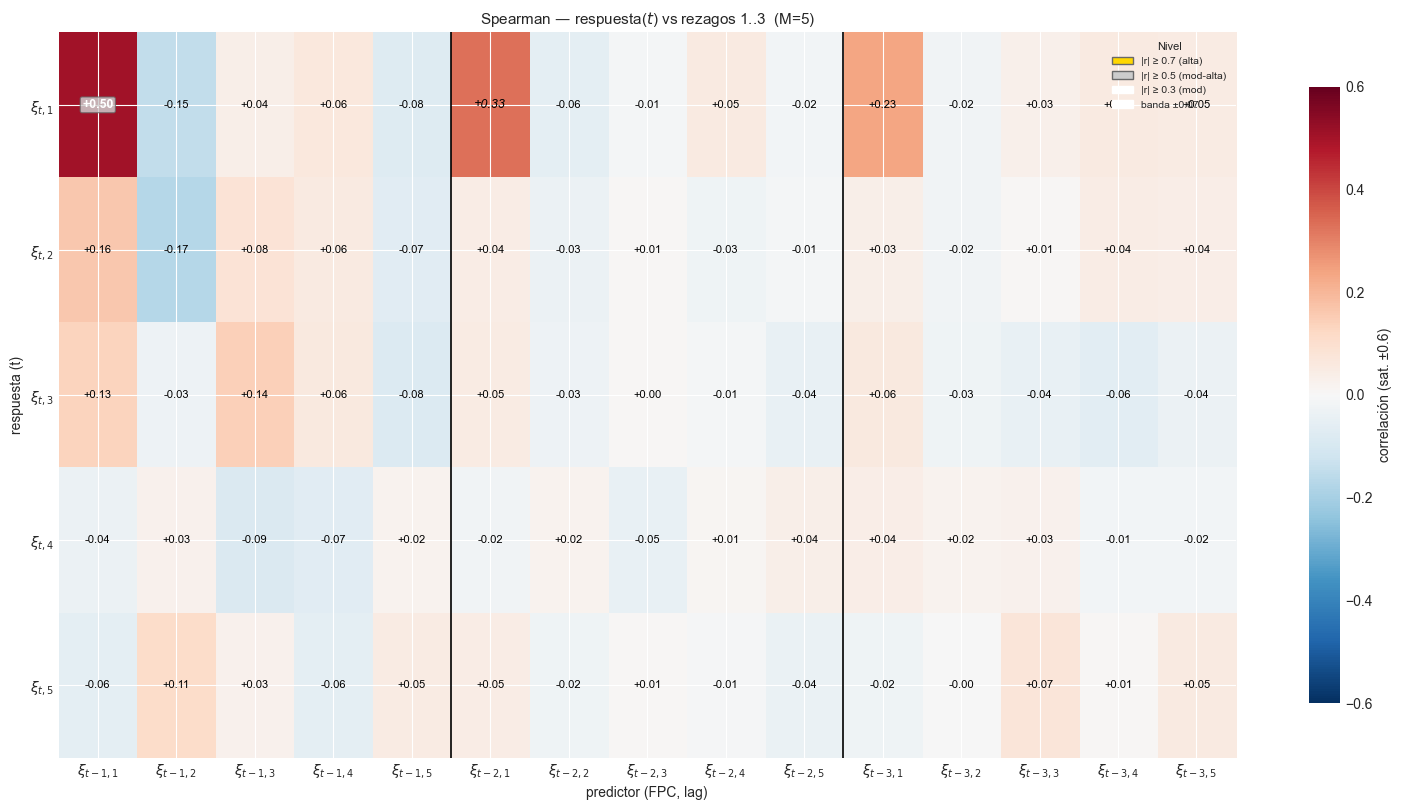

componentes : 5 -> índices [0, 1, 2, 3, 4]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4']
[functional] 10 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415]   sd_i|x - Gamma| = [0.1087 0.1121 0.1141 0.1124]
FPC 3: G* = [-0.336, 0.353]   sd_i|x - Gamma| = [0.0907 0.0899 0.0922 0.0944]
FPC 4: G* = [-0.314, 0.258]   sd_i|x - Gamma| = [0.0822 0.079  0.077

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.0932,0.0832,0.1275,-0.0160,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1384,0.1187,0.1630,-0.8855,0.1570,0.3963


contrato_ok = True   (M=5, K=8, T0=700, n_components=5)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 6   ·   escenario_101_1_r01_m06
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 6   <- DIFIERE de la regla: es un punto de sensibilidad
M = 6   var. explicada = 91.8036%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893 0.998 0.988 1.088]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 6)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18  9.734e-18 -5.016e-18  4.877e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106 0.093 0.084 0.075]   <- NO se divide
  [test]  media = [ 0.058  0.007  0.001 -0.007  0.005 -0.001]
  [test]  std   = [0.224 0.129 0.1   0.093 0.083 0.078]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gating

[fun

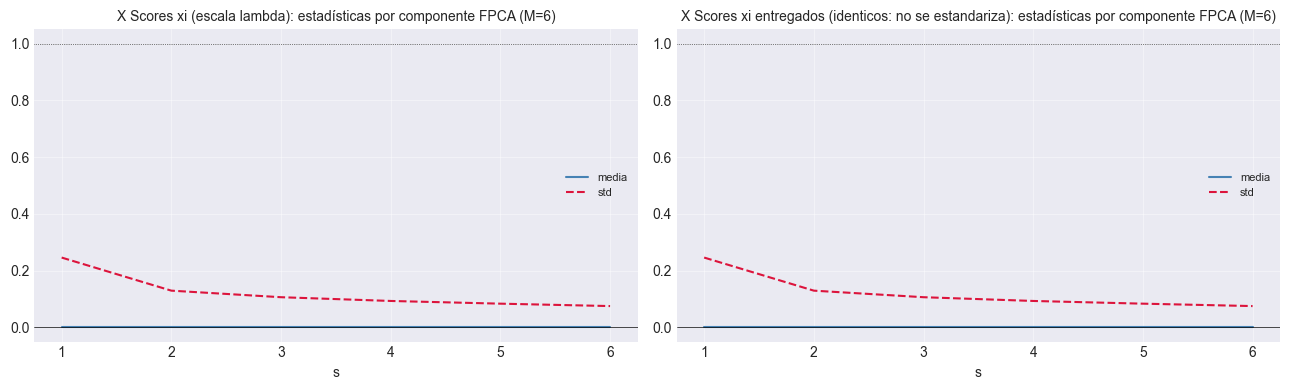

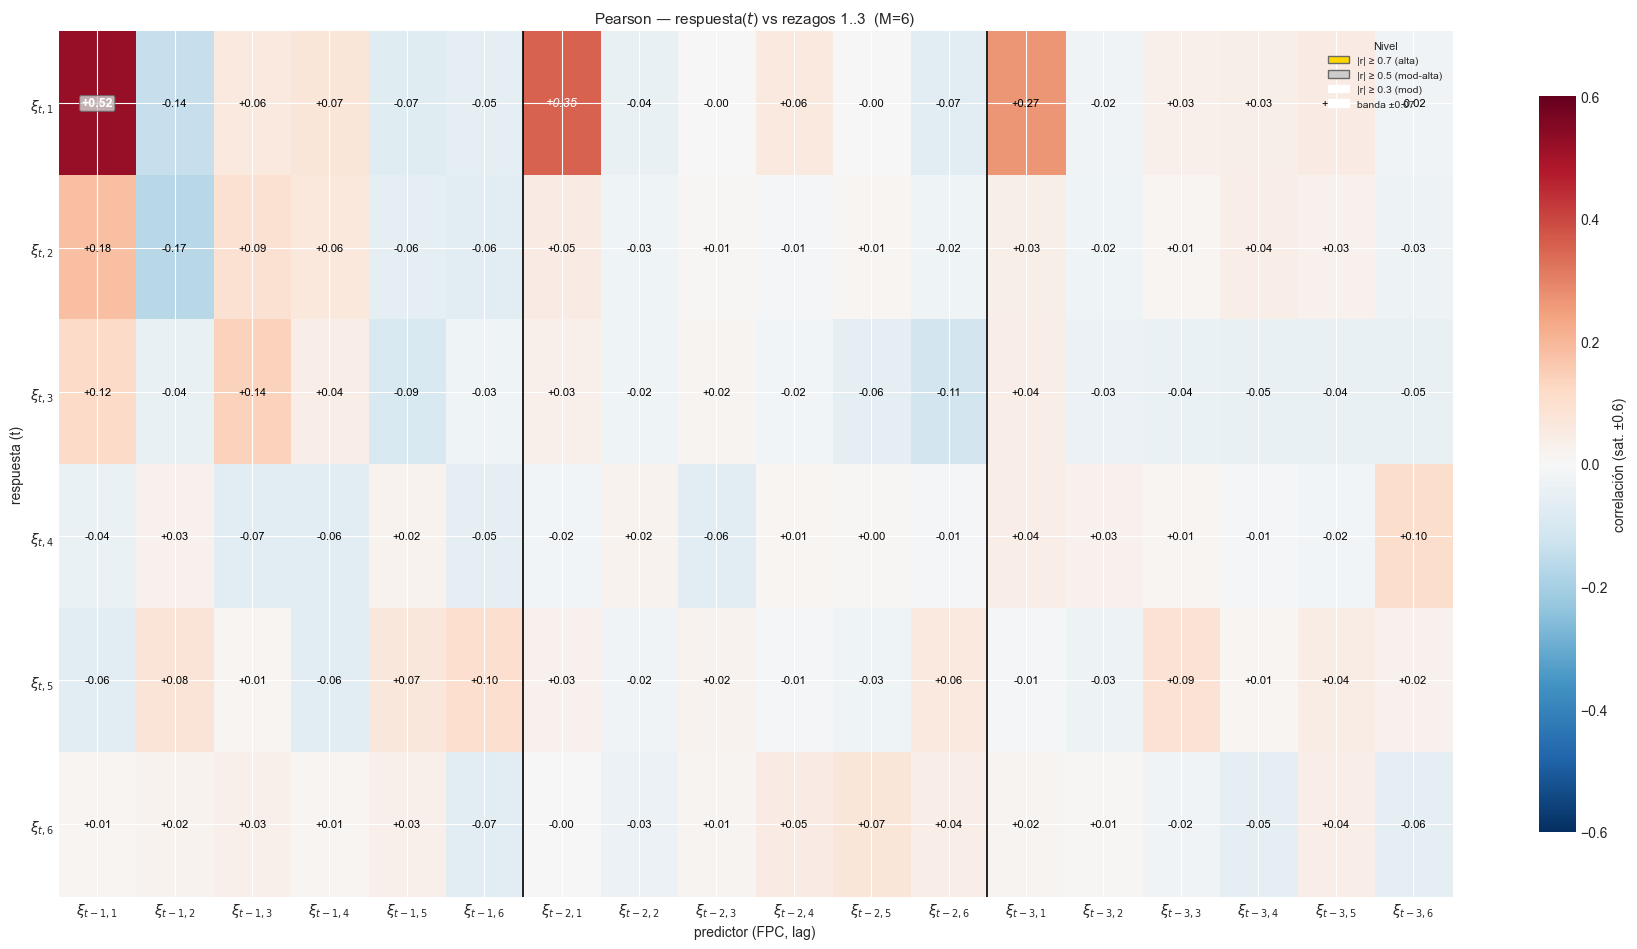

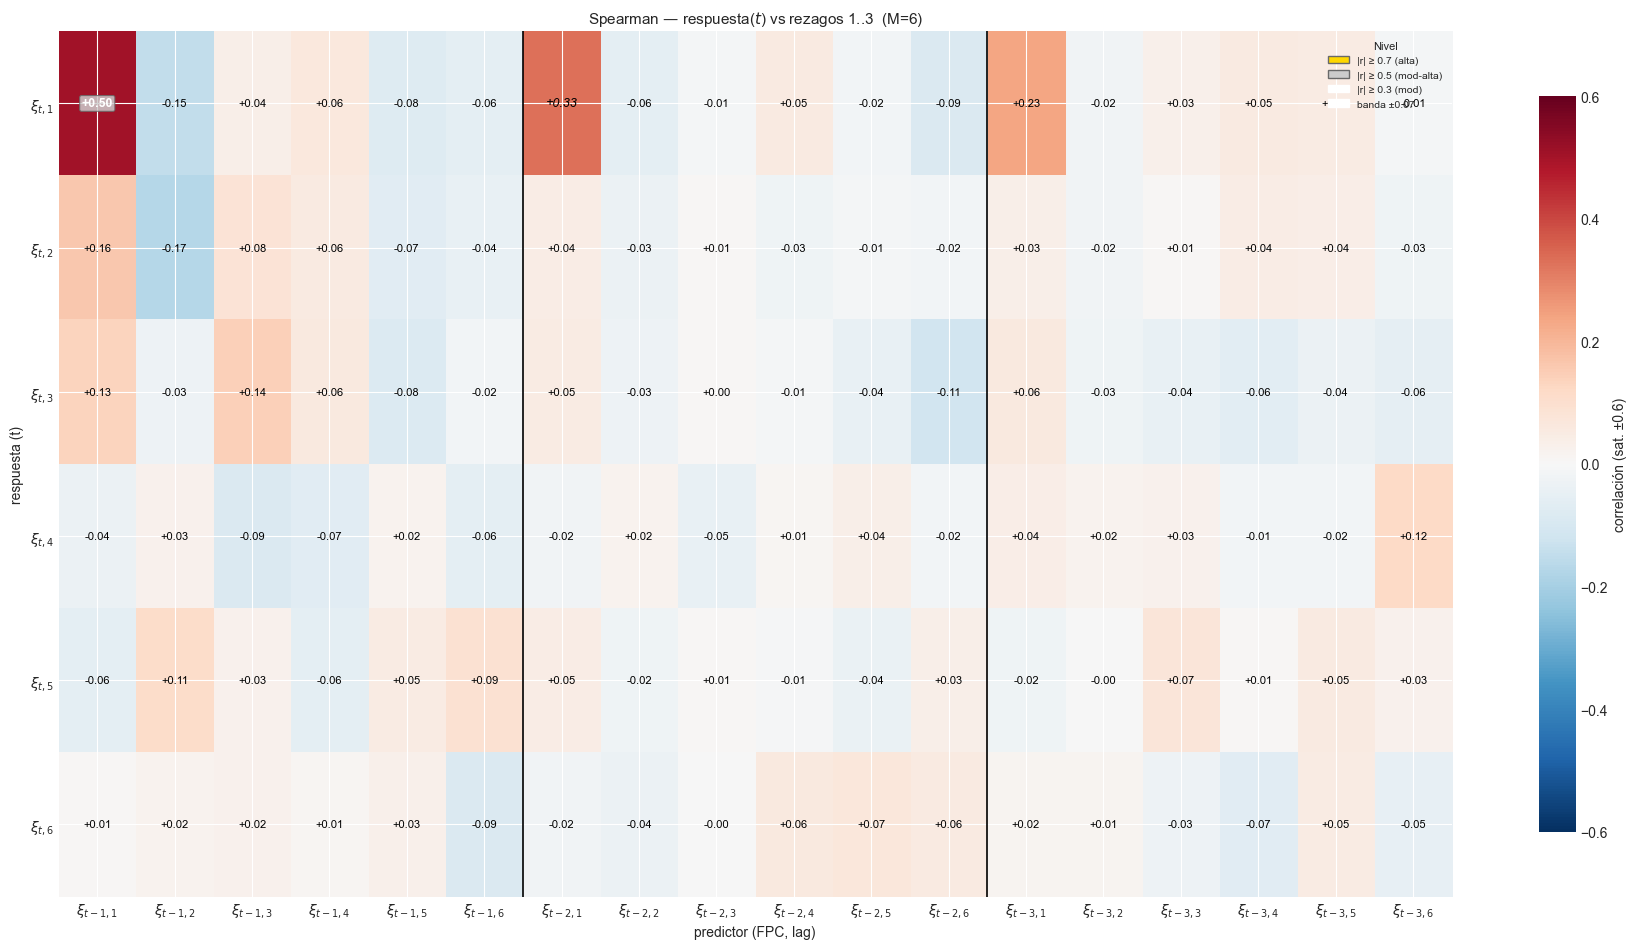

componentes : 6 -> índices [0, 1, 2, 3, 4, 5]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4']
[functional] 12 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415]   sd_i|x - Gamma| = [0.1087 0.1121 0.1141 0.1124]
FPC 3: G* = [-0.336, 0.353]   sd_i|x - Gamma| =

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.0932,0.0832,0.0783,0.1193,-0.0134,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1384,0.1187,0.1154,0.1551,-0.9339,0.1642,0.4053


contrato_ok = True   (M=6, K=8, T0=700, n_components=6)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 7   ·   escenario_101_1_r01_m07
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 7   (coincide con la regla)
M = 7   var. explicada = 95.9673%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893 0.998 0.988 1.088 1.015]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 7)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18  9.734e-18 -5.016e-18  4.877e-18
  1.566e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106 0.093 0.084 0.075 0.071]   <- NO se divide
  [test]  media = [ 0.058  0.007  0.001 -0.007  0.005 -0.001  0.004]
  [test]  std   = [0.224 0.129 0.1   0.093 0.083 0.078 0.071]
  rango que vera MATLAB: [-0.797, 0.785]   <- de ahi sale la grilla G* y con ella la escala del gat

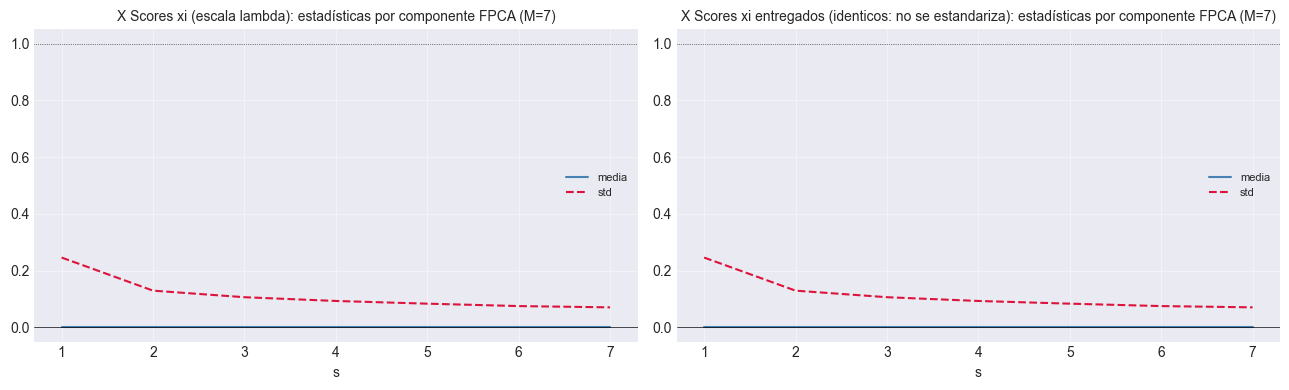

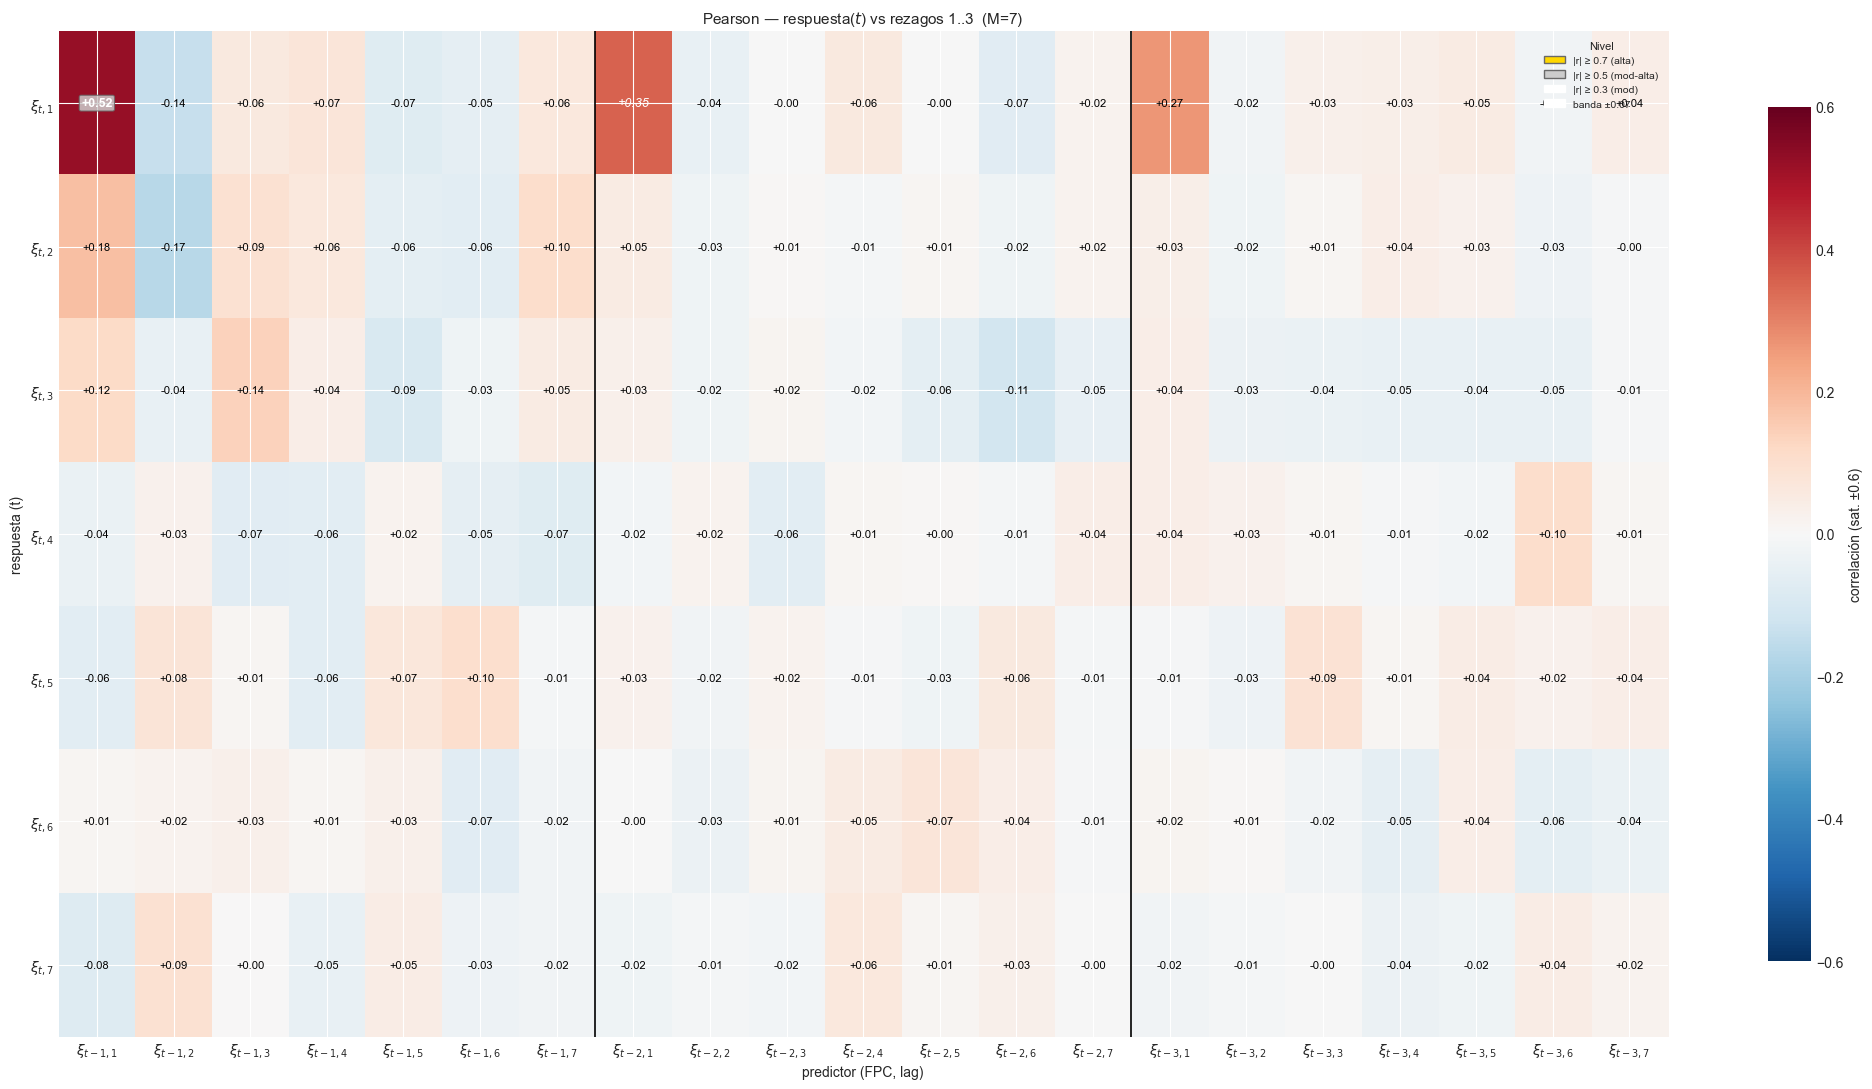

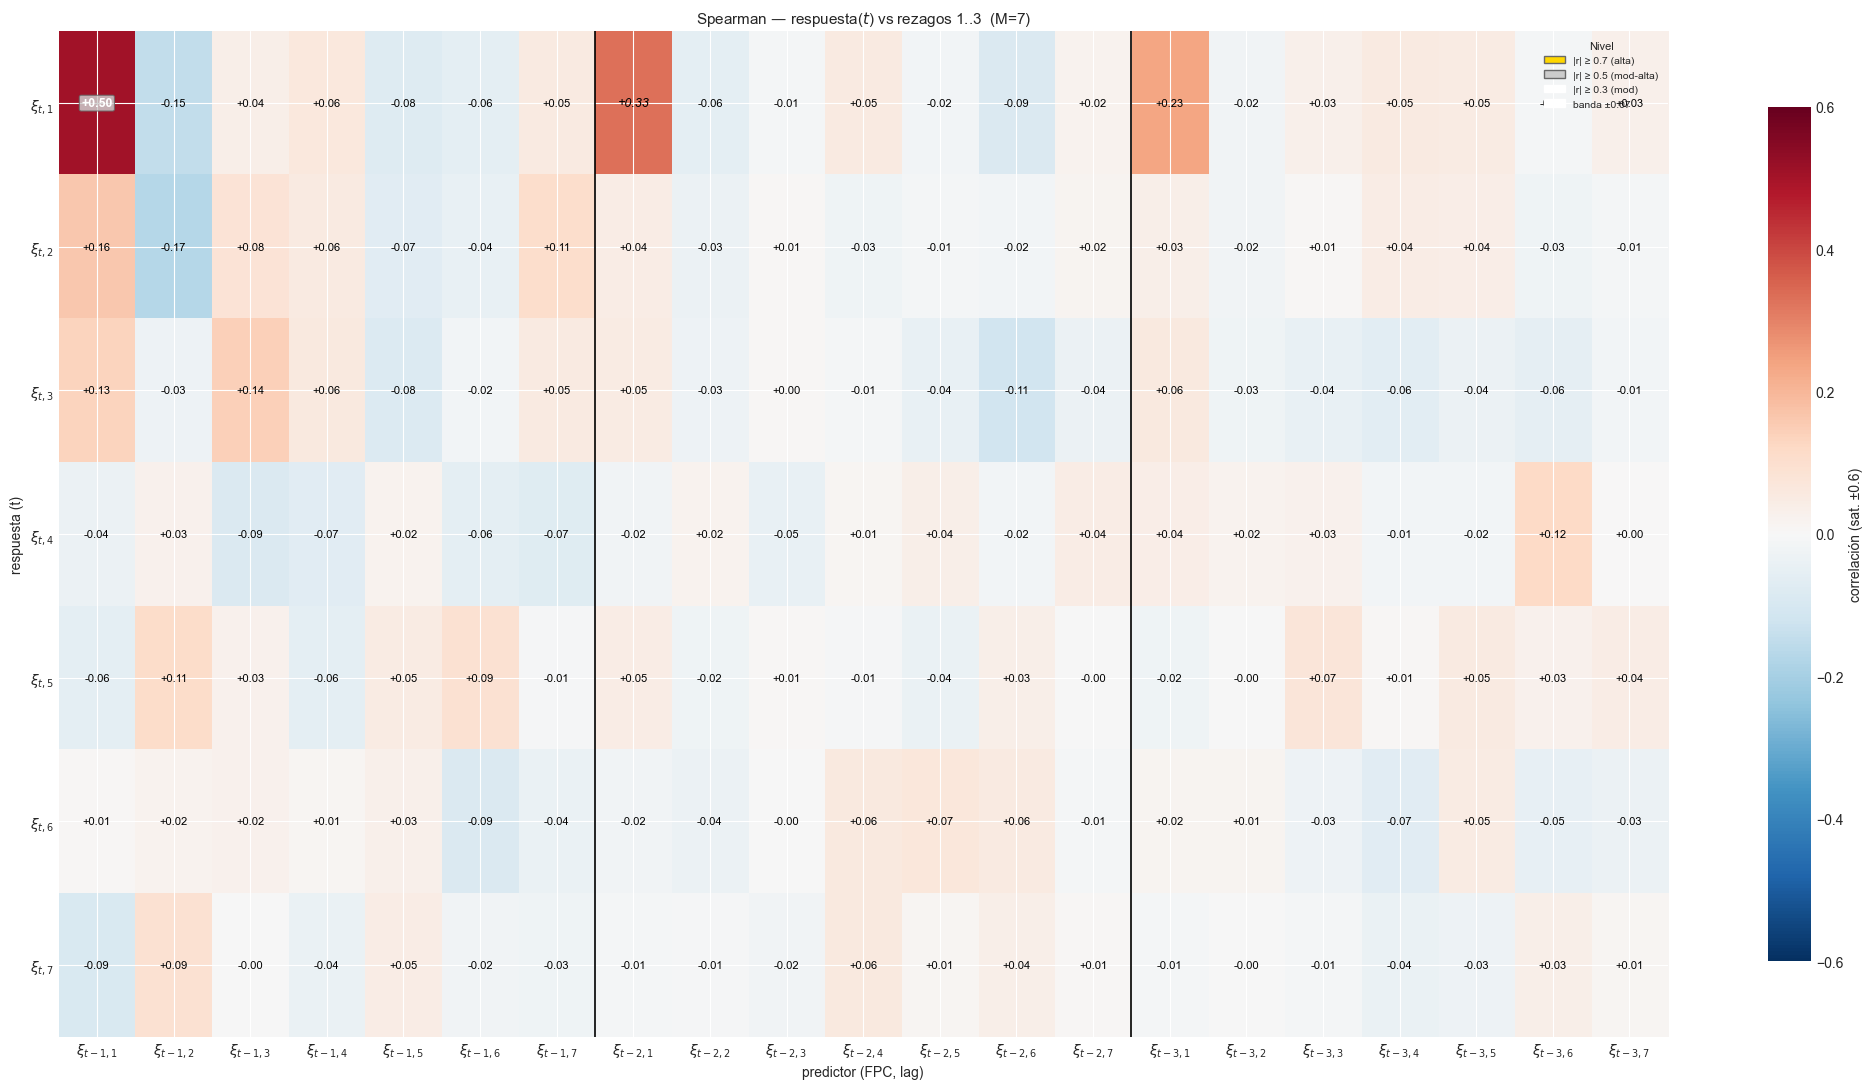

componentes : 7 -> índices [0, 1, 2, 3, 4, 5, 6]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4']
[functional] 14 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
  fpc_7: train (696, 5) · test (300, 5)
FPC 1: G* = [-0.797, 0.749]   sd_i|x - Gamma| = [0.2196 0.216  0.2217 0.2182]
FPC 2: G* = [-0.452, 0.415

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.0932,0.0832,0.0783,0.0712,0.1124,-0.0119,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1384,0.1187,0.1154,0.1013,0.1474,-0.9481,0.1694,0.4116


contrato_ok = True   (M=7, K=8, T0=700, n_components=7)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True

M = 8   ·   escenario_101_1_r01_m08
M(95 %) según la regla : 7   (K disponible = 8)
M de este punto        : 8   <- DIFIERE de la regla: es un punto de sensibilidad
M = 8   var. explicada = 100.0000%
[train] max|media xi| = 1.43e-17   (~ 0)
[test]  max|media xi| = 0.058
[test]  var xi / lambda = [0.832 0.995 0.893 0.998 0.988 1.088 1.015 1.053]
[holdout] ajustado con 700 filas = T0 (train[1:700]) -> ok=True

SCORES_STD (1000, 8)   (= SCORES: transformacion identidad)
  [train] media = [-1.427e-17  6.443e-18 -4.282e-18  9.734e-18 -5.016e-18  4.877e-18
  1.566e-18 -5.288e-18]   <- NO se resta
  [train] std   = [0.246 0.129 0.106 0.093 0.084 0.075 0.071 0.069]   <- NO se divide
  [test]  media = [ 0.058  0.007  0.001 -0.007  0.005 -0.001  0.004  0.003]
  [test]  std   = [0.224 0.129 0.1   0.093 0.083 0.078 0.071 0.071]
  rango que vera MATLAB: [-0.797, 

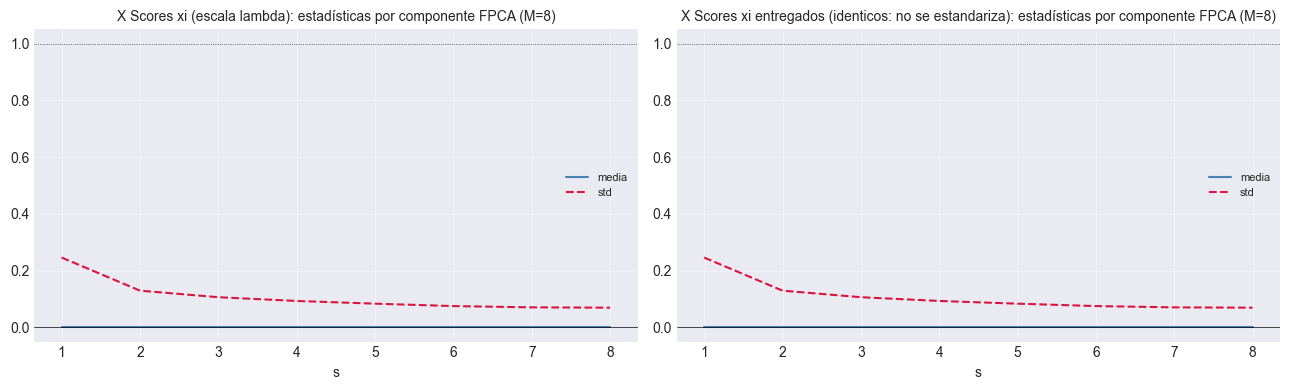

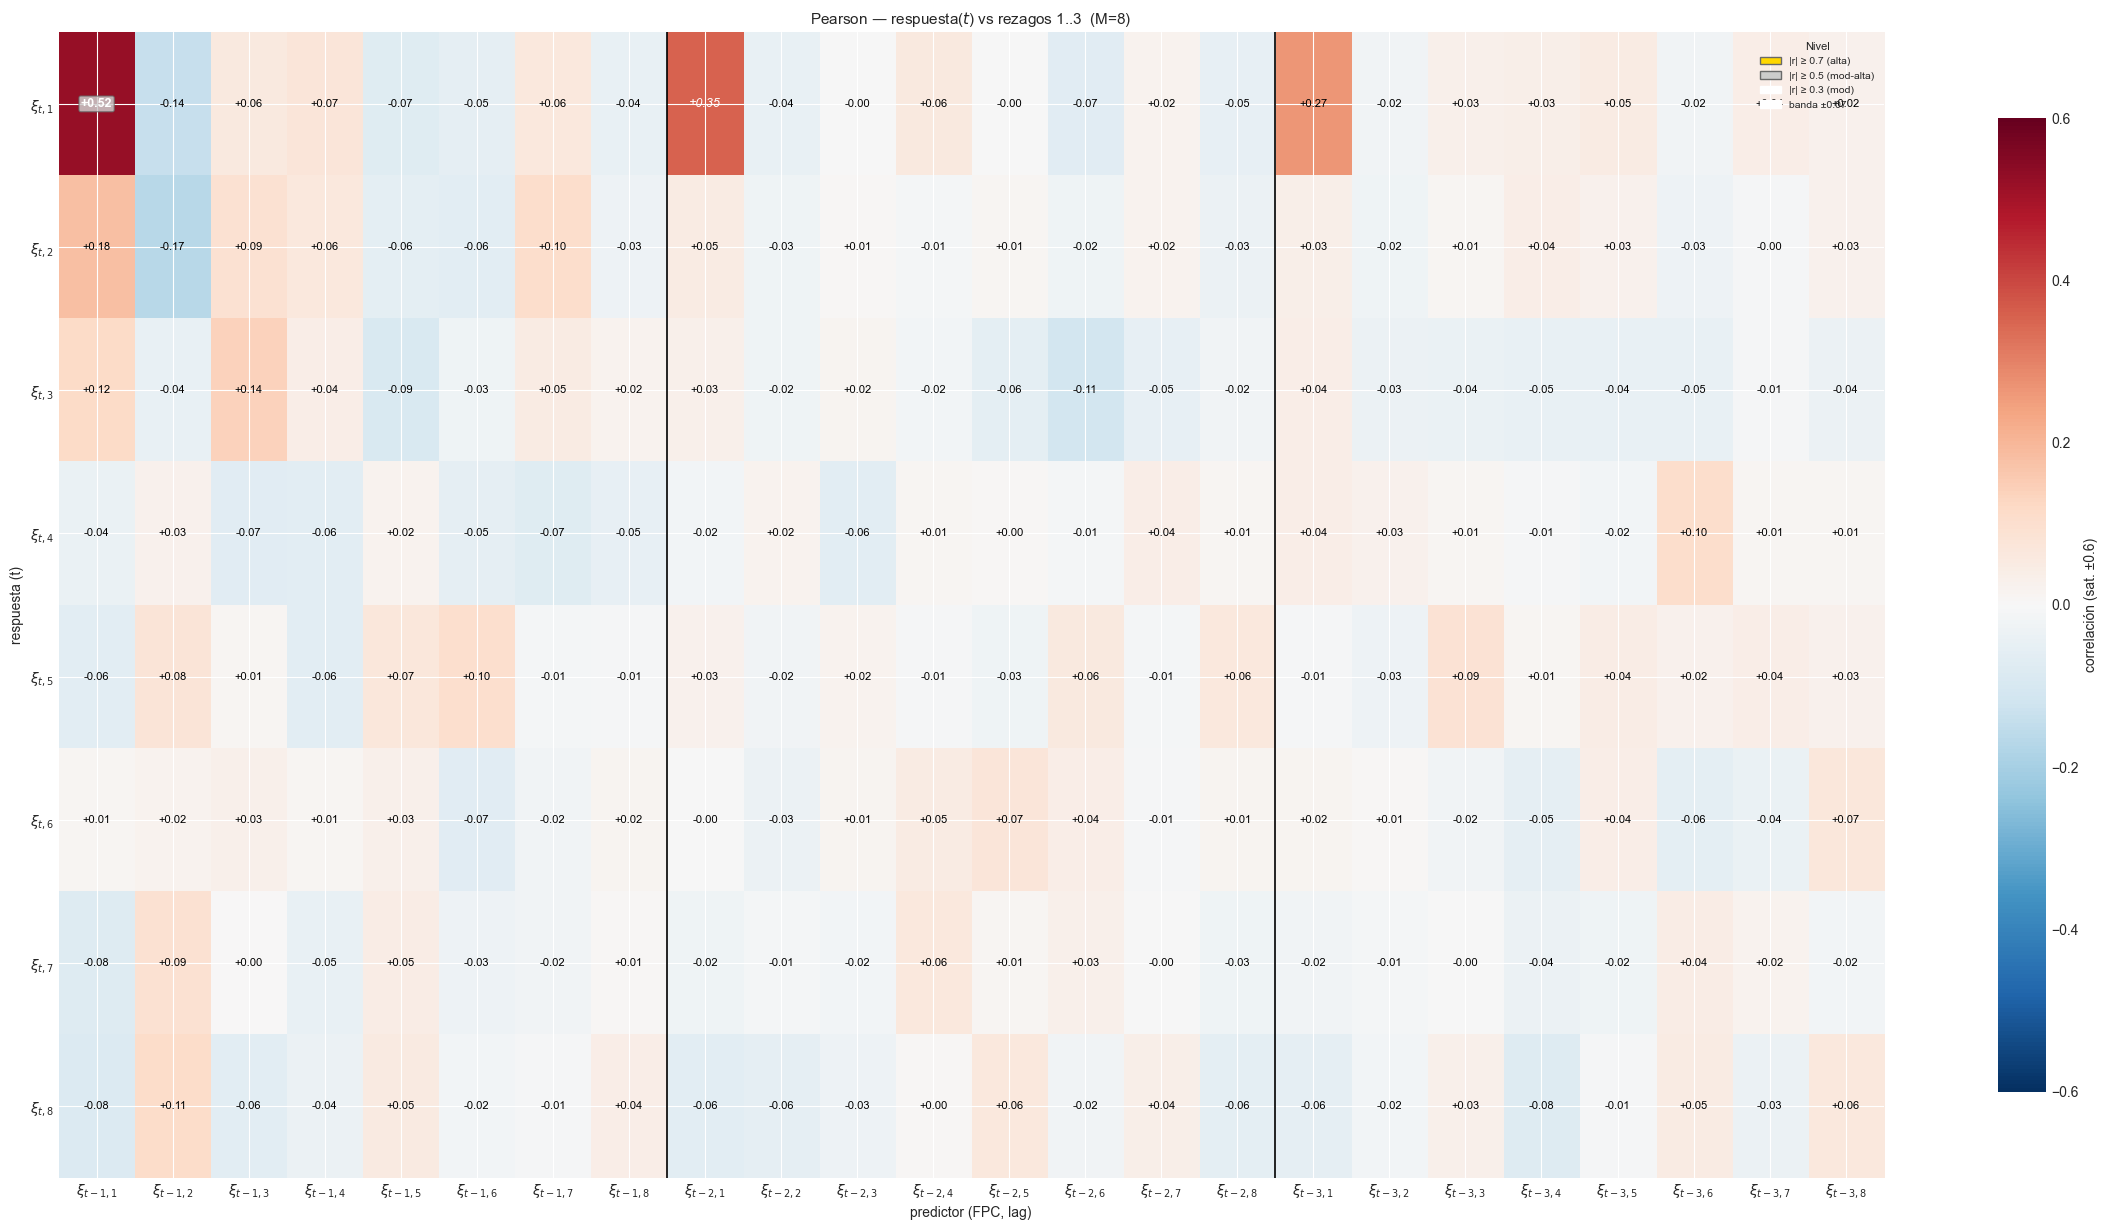

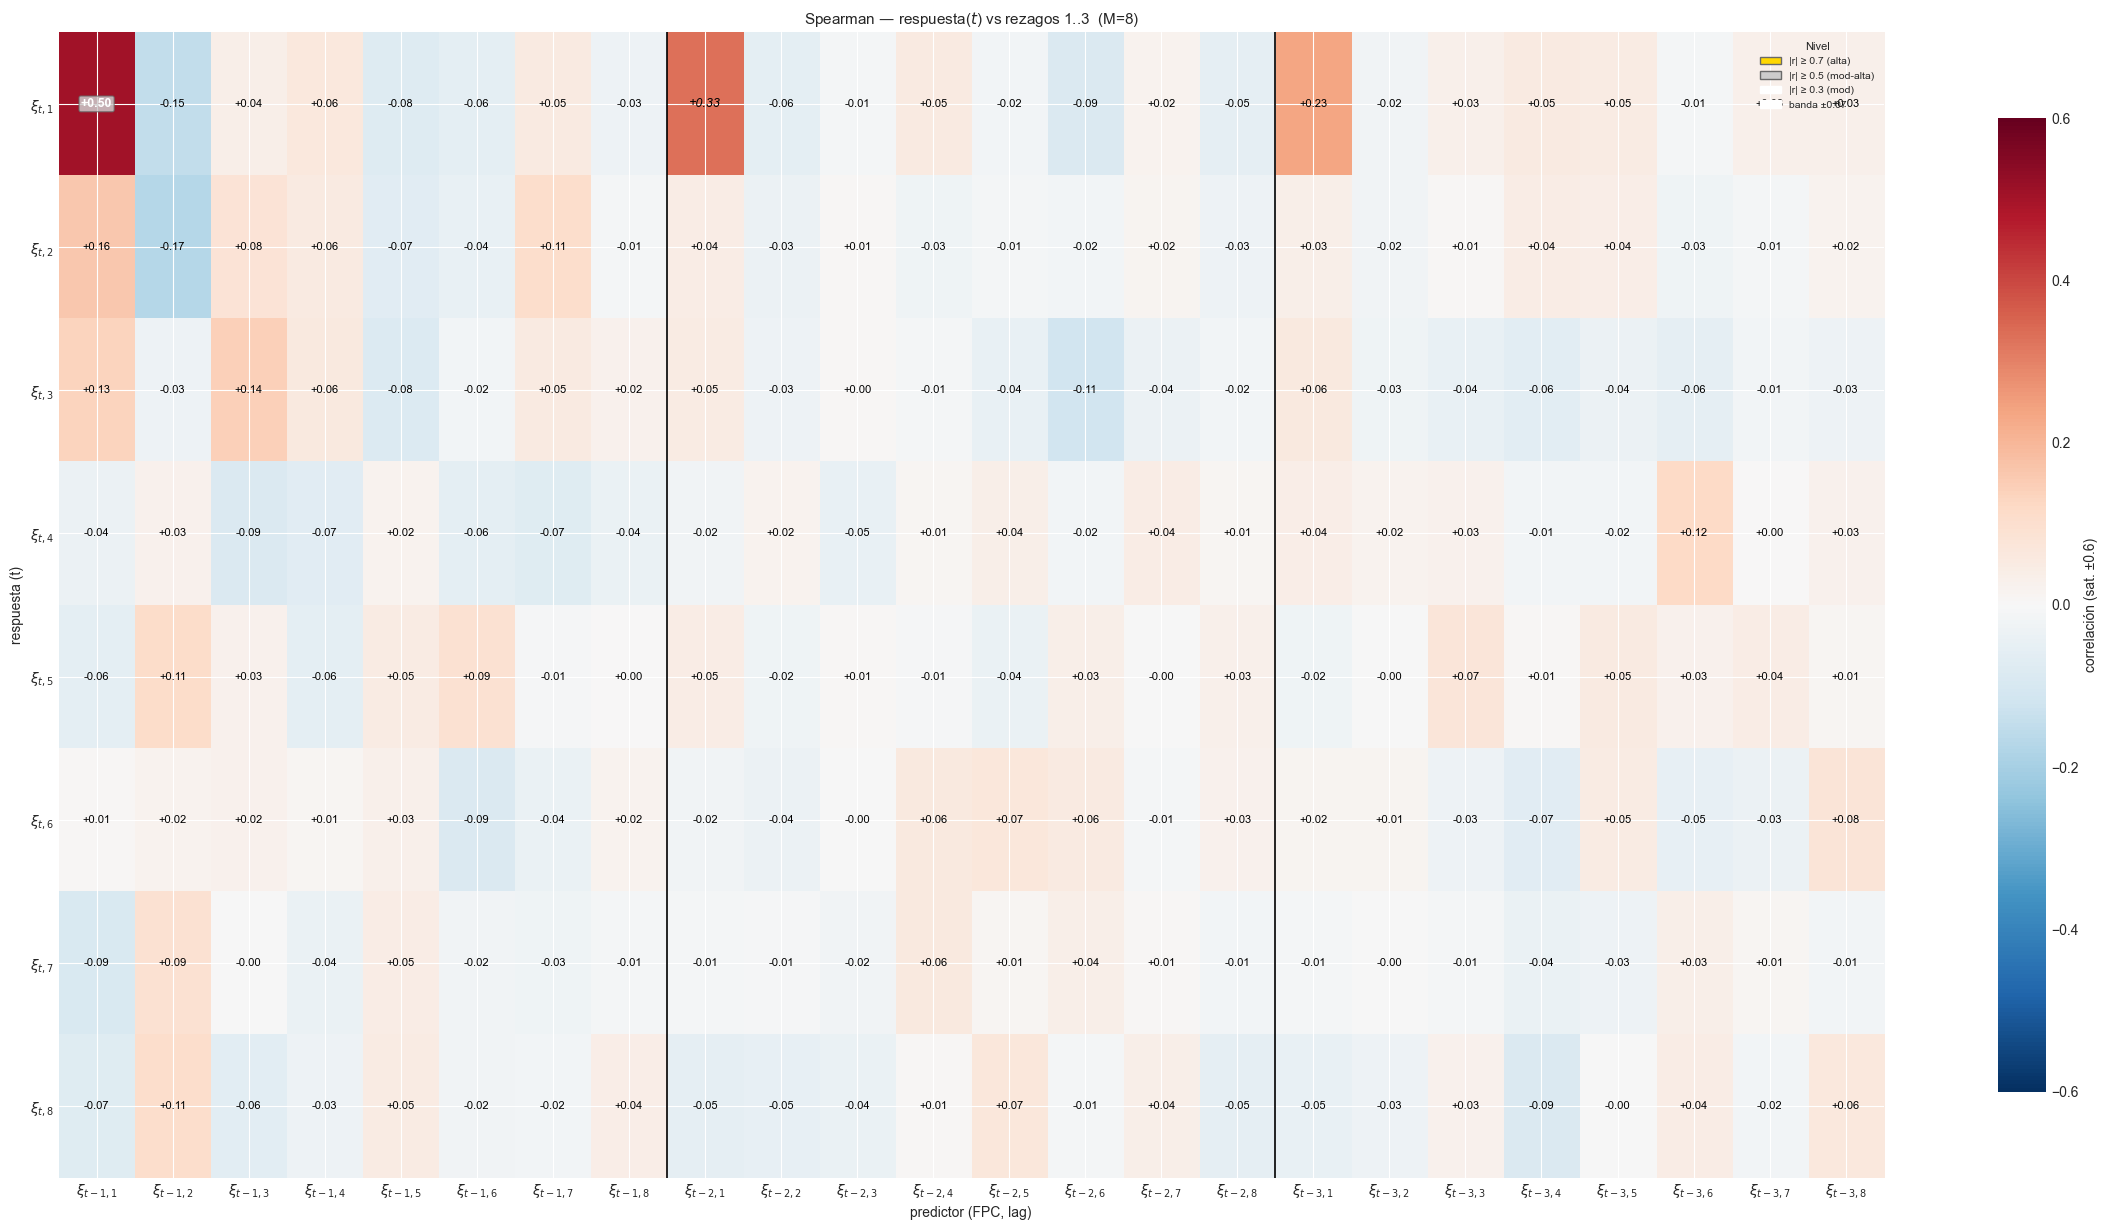

componentes : 8 -> índices [0, 1, 2, 3, 4, 5, 6, 7]
N_LAGS      : 4   ·   p = 4 covariable(s) por componente (rezago propio)
n_train_eff : 696   n_test_eff : 300
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_1_lag3', 'fpc_2_lag3', 'fpc_3_lag3', 'fpc_4_lag3', 'fpc_5_lag3', 'fpc_6_lag3', 'fpc_7_lag3', 'fpc_8_lag3', 'fpc_1_lag4', 'fpc_2_lag4', 'fpc_3_lag4', 'fpc_4_lag4', 'fpc_5_lag4', 'fpc_6_lag4', 'fpc_7_lag4', 'fpc_8_lag4']
[functional] 16 datasets + datasets_manifest.json
  fpc_1: train (696, 5) · test (300, 5)
  fpc_2: train (696, 5) · test (300, 5)
  fpc_3: train (696, 5) · test (300, 5)
  fpc_4: train (696, 5) · test (300, 5)
  fpc_5: train (696, 5) · test (300, 5)
  fpc_6: train (696, 5) · test (300, 5)
  fpc_7: train (696, 5) · test (300, 5)
  fpc_8: train (696, 5) · test (300, 5)
FPC 1

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_fpc5,RMSE_fpc6,RMSE_fpc7,RMSE_fpc8,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,,,,,
media_incondicional,300.0000,0.2315,0.1292,0.1004,0.0932,0.0832,0.0783,0.0712,0.0713,0.1073,-0.0107,0.1122,0.3350
persistencia_lag1,300.0000,0.2269,0.1905,0.1405,0.1384,0.1187,0.1154,0.1013,0.0957,0.1409,-0.9300,0.1735,0.4165


contrato_ok = True   (M=8, K=8, T0=700, n_components=8)
estandarizador ajustado con 700 filas (T0=700)
verificación FPCA: todo_ok = True


In [19]:
# -- [CONFIG] Comunes a TODOS los puntos del barrido -------------------------
# [CONFIG] rezagos PROPIOS por componente: la componente k se predice con
# xi_{k,t-1}, ..., xi_{k,t-N_LAGS} y con nada mas. p = N_LAGS por componente.
# Admite 1, 2, 3 o 4; HP_BY_TYPE tiene un peldano de apij/bpij para cada uno.
# Subirlo NO rompe la reutilizacion de trazas entre puntos del barrido: con
# rezago propio el diseno de la componente k sigue sin depender de M.
N_LAGS      = 4
assert N_LAGS in (1, 2, 3, 4), "N_LAGS admitido: 1, 2, 3 o 4 (ver HP_BY_TYPE)."
# burn=1000, N=30: sobre la corrida 103_N_LAGS=4 original (nsim=2600,
# burn=600, N=25). (1) burn=600 no alcanzaba: alpha_h arranca en 0
# (psbp_train.m:57) y tiene que trepar hasta la media del argumento probit
# -mientras no llega, m_val choca contra el clip M_TRUNC = 6 (psbp_train.m:
# 100), Phi(-6) ~ 1e-9, todo el peso al ultimo atomo. (2) N: se probo N=50
# (mas conservador contra el truncamiento que _03 marco con N=25), pero baja
# el escape de w_j=0 con HP_BY_TYPE fijo (escape = bpij/(N+2*bpij)): con
# apij=1, bpij=5 (Chung & Dunson, ver mas abajo) da 8.3 % a N=50 contra
# 14.3 % a N=25. N=30 es el punto medio: menos conservador que 50 sin volver
# al 25 que _03 marco como insuficiente, y a Chung/bpij=5 da escape=12.5 %
# (espera~8 iter). Sigue existiendo el riesgo de que N=30 tambien tope en
# algun punto del barrido -_03 lo dira-, es la contraparte de no subir mas.
# Quedan (3000-1000) x 2 = 4000 draws, igual que antes.
MCMC_CONFIG = {"nsim": 3000, "burn": 1000, "N": 30, "M": 50}   # ojo: ese M es G*
N_CHAINS    = 2

# Priors globales
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Un peldano por rezago propio. Solo se leen los rezagos 1..N_LAGS; los demas
# quedan declarados para que subir N_LAGS no obligue a tocar nada mas.
#
# w_j=0 es absorbente (psbp_train.m:202-221): con w_j=0 ningun gamma_hj de
# los N atomos puede volver a 1 salvo por la moneda de esa linea, con
# probabilidad
#
#     escape = pwj * b_val / ((1 - pwj) + pwj * b_val),
#     b_val  = B(apij, bpij+N) / B(apij, bpij)
#
# que con apij=1 y pwj=0.5 (HP_GLOBAL) se cierra en forma cerrada:
#
#     escape = bpij / (N + 2*bpij)
#
# Se probo calibrar bpij DESPEJANDO esta formula desde un escape objetivo
# (0.10-0.35, escalonado y luego uniforme por rezago). No sirvio: en la
# corrida 103 (N_LAGS=4, N=50) el patron de p_j sin converger salio disperso
# entre rezagos y componentes -no sistematicamente en el rezago con menor
# escape-, asi que subir el escape objetivo no atacaba la causa real. Se
# vuelve al valor CONSTANTE de `references/Case1_01.m`, la implementacion
# original de Chung & Dunson (2009): apij=1, bpij=5 para las cuatro, sin
# escalera ni despeje desde N.
_N_ATOMOS = MCMC_CONFIG["N"]

# apij=1, bpij=5 CONSTANTE para las cuatro, igual para todas las covariables:
# es el valor de `references/Case1_01.m`, la implementacion ORIGINAL de
# Chung & Dunson (2009) (linea "apij=ones(p,1);bpij=5*ones(p,1);"), no una
# calibracion propia. Se abandona la calibracion por escape objetivo -que en
# la corrida 103 con escaleras 0.10-0.35 no evito que p_j fallara en
# rezagos/componentes casi al azar, ver notas de esa exploracion- y se vuelve
# al valor publicado, que a N=50 da escape=8.3% (espera~12 iter) y
# E[pi]=0.167, igual para los cuatro rezagos: no hay ESCALERA de E[pi] por
# rezago en el paper tampoco.
HP_BY_TYPE = {
    tipo: {"apij": 1.0, "bpij": 5.0}
    for tipo in ("own_lag1", "own_lag2", "own_lag3", "own_lag4")
}
_escape_chung = 5.0 / (_N_ATOMOS + 10.0)
print(f"HP_BY_TYPE = apij=1, bpij=5 (Chung & Dunson original) para las 4  ·  "
      f"N={_N_ATOMOS}  escape={_escape_chung:.3f} (espera~{1/_escape_chung:.0f} iter)  "
      f"E[pi]={1/6:.3f}")


# sd_gate_objetivo  dispersion DESEADA del argumento probit a traves de i, en
#                   unidades probit. Es LA perilla del gating: Phi se mueve de
#                   0.21 a 0.79 sobre +/- sd_gate, asi que 0.8 da pesos que
#                   discriminan sin saturar. Por debajo de ~0.3 el gating es
#                   decorativo; por encima de ~1.5 v_h satura y la mezcla se
#                   colapsa en el ultimo atomo.
# cv_psi            sd(psi)/E(psi) a priori. 1.0 = prior debilmente informativo,
#                   que deja a psi ir de ~0 a ~3 x mupsij. Bajarlo a 0.3 amarra
#                   psi a mupsij: gating impuesto en vez de aprendido.
# razon_Etau_lambda E[tau] * lambda_k, ADIMENSIONAL: 3.0 = el atomo explica 2/3
#                   de la varianza del score. Reemplaza a e_tau_objetivo, que
#                   estaba en 1/var(y) absoluto y con scores crudos de sd 0.246
#                   pedia una sd residual de 0.577, o sea 2.35 x la varianza
#                   TOTAL de la serie: el prior afirmaba que el ruido supera a
#                   la senal, y eso ensanchaba la banda de forma sistematica.
# atau              se conserva la escalera original (2.5 / 2.0 / 0.5): peldano
#                   mas difuso a medida que sube k.
_PELDANO_ALTO = {"sd_gate_objetivo": 0.8, "cv_psi": 1.0,
                 "atau": 0.5, "razon_Etau_lambda": 1.5}

HP_ESCALERA = {
    0: {"sd_gate_objetivo": 0.8, "cv_psi": 1.0,
        "atau": 2.5, "razon_Etau_lambda": 2.5},
    1: {"sd_gate_objetivo": 0.8, "cv_psi": 1.0,
        "atau": 2.0, "razon_Etau_lambda": 2.5},
    **{k: dict(_PELDANO_ALTO) for k in range(2, 8)},
}


assert all(k in HP_ESCALERA for k in range(max(M_FPCA_LIST))), (
    f"HP_ESCALERA necesita peldanos 0..{max(M_FPCA_LIST) - 1} para "
    f"M_FPCA_LIST={list(M_FPCA_LIST)}.")

# Convencion de E[tau] de la escalera; falla si los peldanos no coinciden.
_CLAVE_ETAU = clave_etau({k: HP_ESCALERA[k] for k in range(max(M_FPCA_LIST))})

print("\nescalera por componente (btau se despeja en procesar_punto):")
print(f"  {'k':>2} {'sd_gate':>8} {'cv_psi':>7} {'atau':>6} {_CLAVE_ETAU:>18}")
for _k in range(max(M_FPCA_LIST)):
    _e = HP_ESCALERA[_k]
    print(f"  {_k:>2} {_e['sd_gate_objetivo']:>8.2f} {_e['cv_psi']:>7.2f} "
          f"{_e['atau']:>6.2f} {_e[_CLAVE_ETAU]:>18.2f}")
print("  (mupsij y taupsij ya no se fijan aqui: se despejan por covariable en "
      "procesar_punto)")

print("")
print("inclusion por tipo (apij/bpij ya no son de la escalera):")
for _t, _c in HP_BY_TYPE.items():
    print(f"  {_t:>10}  apij={_c['apij']:.4f}  bpij={_c['bpij']:.4f}  "
          f"E[pi]={_c['apij']/(_c['apij']+_c['bpij']):.3f}")

print(f"N_LAGS      : {N_LAGS}")
print(f"MCMC_CONFIG : {MCMC_CONFIG}   (su 'M' es la grilla G* del stick-breaking)")
print(f"N_CHAINS    : {N_CHAINS}")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) x {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

RESUMEN = [procesar_punto(M) for M in M_FPCA_LIST]

## 5. Resumen del barrido

In [20]:
resumen_df = pd.DataFrame(RESUMEN).set_index("M")
display(resumen_df[["experiment_id", "var_acum", "K", "coincide_regla_95",
                    "n_components", "p_covariables", "contrato_ok"]]
        .style.format({"var_acum": "{:.4%}"})
        .set_caption(f"Barrido en M · {EXPERIMENT_BASE} · "
                     f"K disponible = {resumen_df['K'].iloc[0]}"))

_fallidos = [r for r in RESUMEN if not r["contrato_ok"]]
for r in _fallidos:
    print(f"\n[FALLA] M={r['M']} ({r['experiment_id']}):")
    for p in r["problemas"]:
        print(f"  - {p}")
assert not _fallidos, (
    f"El contrato falla en M = {[r['M'] for r in _fallidos]}. No lanzar MATLAB: "
    f"psbp_fd_iteracion.m leería artefactos inconsistentes.")

print(f"\n{'='*70}\nListo. Siguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"con M_FPCA_LIST = [{M_ENTRENO}]   (solo se entrena M={M_ENTRENO}: "
      f"los M menores reutilizan sus trazas)\n{'='*70}")

,experiment_id,var_acum,K,coincide_regla_95,n_components,p_covariables,contrato_ok
M,,,,,,,
1,escenario_101_1_r01_m01,50.5650%,8,False,1,4,True
2,escenario_101_1_r01_m02,64.5620%,8,False,2,4,True
3,escenario_101_1_r01_m03,74.0083%,8,False,3,4,True
4,escenario_101_1_r01_m04,81.2539%,8,False,4,4,True
5,escenario_101_1_r01_m05,87.0908%,8,False,5,4,True
6,escenario_101_1_r01_m06,91.8036%,8,False,6,4,True
7,escenario_101_1_r01_m07,95.9673%,8,True,7,4,True
8,escenario_101_1_r01_m08,100.0000%,8,False,8,4,True



Listo. Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
con M_FPCA_LIST = [8]   (solo se entrena M=8: los M menores reutilizan sus trazas)
